In [235]:
import sys
import numpy as np
import pandas as pd
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pprint import pprint
import yaml
from tqdm import tqdm

# notebook上で.pyファイルを設定しなおして、リロードする場合
import importlib

#- sys.modules に一度読み込まれたモジュールは、再度 import してもキャッシュから取得されます。
#- importlib.reload() はそのキャッシュを明示的に更新する方法
# .pyファイルのリロードする場合
#importlib.reload(ecg_reader)

#### Set Project Root Directory

In [236]:
#config.yamlを配置したフォルダをルートフォルダと設定する
def find_project_root(marker: str = "config.yaml") -> Path:
    path = Path.cwd()
    while not (path / marker).exists() and path != path.parent:
        path = path.parent
    return path

project_root = find_project_root()
print("RootDirectory Path:",project_root)

# system Pathに追加
sys.path.append(str(project_root))
#pprint(sys.path)
#project_root = Path.cwd().parent で設定するとuserName/projectsがparaentsフォルダ賭して認識されるため上記方法で固定とする

### フォルダ構成の確認
directory_file_list = list(project_root.glob("*"))
pprint(directory_file_list)

RootDirectory Path: /Users/yohe/Desktop/ECG-Analysis
[PosixPath('/Users/yohe/Desktop/ECG-Analysis/analysis_test.ipynb'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/config.yaml'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/README.md'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/.git'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/MEMO.md'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/notebooks'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/src')]


In [237]:
from src.data_utils.ecg_reader import load_table_as_pandas, load_ecg_metadata_by_id, extract_lead_features, plot_ecg_waveform
from src.system_utils import detect_os, windows_to_wsl_path, check_config_paths
from src.config_loader import DataConfig

### Set CONFIG

In [238]:
# OSを判定し、WSLの環境ではWindowsのディレクトリにアクセス可能なようにRootDirectoryを変更
detected_os = detect_os()
print("System Environment:", detected_os)

#wsl
#set_root_directory = r"C:\Users\yohei\Desktop\physionet-ecg-image-digitization"
#mac
set_root_directory = "/Users/yohe/Desktop/physionet-ecg-image-digitization"

if detected_os == "wsl":
    ECG_DATASET_ROOT = windows_to_wsl_path(set_root_directory)
else:
    ECG_DATASET_ROOT = Path(set_root_directory)

print("Project Root:", ECG_DATASET_ROOT)

System Environment: mac
Project Root: /Users/yohe/Desktop/physionet-ecg-image-digitization


In [239]:
# datareader用の設定
CONFIG = DataConfig(config_yaml_path=project_root/"config.yaml", 
                    root=ECG_DATASET_ROOT)
#CONFIGのパラメータを確認
pprint(CONFIG.__dict__)

# CONFIG内のパスが存在するか確認
check_config_paths(CONFIG)

{'sample_submission_csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/sample_submission.parquet'),
 'test_csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/test.csv'),
 'test_data_dir': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/test'),
 'train_csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train.csv'),
 'train_data_dir': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train')}
すべてのパスが存在します


### read dataframe

In [240]:
train_df = load_table_as_pandas(path=CONFIG.train_csv_path, verbose=True)
test_df = load_table_as_pandas(path=CONFIG.test_csv_path, verbose=True)
sample_submission = load_table_as_pandas(path=CONFIG.sample_submission_csv_path, verbose=True)

Datatype is CSV
Datatype is CSV
Datatype is Parquet


In [241]:
### サンプルデータで出力テストをする

In [242]:
sample_id = 11842146
sample_data_dir = Path(CONFIG.train_data_dir / str(sample_id))
print("Sample Data Directory:", sample_data_dir)
list(sample_data_dir.glob("*"))

Sample Data Directory: /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146


[PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0003.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0001.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0004.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0010.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0011.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0005.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0006.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0012.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146.csv'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0009.pn

### CSVデータ処理

In [243]:
import neurokit2 as nk

In [244]:
### リードデータを抽出する
def extract_lead_signal(ecg_df: pd.DataFrame, lead: str = "I") -> np.ndarray:
    """
    指定されたリードの波形を抽出し、NaNを除去して返す。
    
    Parameters:
        ecg_df (pd.DataFrame): ECGの波形データ（CSV読み込み済み）
        lead (str): 抽出対象のリード名（例："I", "II", "V1"など）

    Returns:
        np.ndarray: NaN除去済みの波形データ
    """
    if lead not in ecg_df.columns:
        raise ValueError(f"リード '{lead}' は存在しません。利用可能なリード: {list(ecg_df.columns)}")

    signal = pd.to_numeric(ecg_df[lead], errors="coerce").dropna().values

    if len(signal) == 0:
        raise ValueError(f"リード '{lead}' に有効な波形データが存在しません。")

    return signal

In [252]:
sample_id = 11842146

# set directory
sample_data_dir = Path(CONFIG.train_data_dir / str(sample_id))
print("Sample Data Directory:", sample_data_dir)

# set csv data path
sample_csv_path = list(sample_data_dir.glob("*.csv"))[0]

ecg_df = pd.read_csv(sample_csv_path)
lead_signal = extract_lead_signal(ecg_df=ecg_df, lead="I")
print("信号長:", len(lead_signal))

Sample Data Directory: /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146
信号長: 2500


### 1. R peakの検出

In [253]:

def detect_r_peaks(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からRピークを検出する関数（NeuroKit2使用）

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 以下のキーを含む辞書
            - "rpeaks": Rピーク位置（int型のnumpy配列）
            - "signals": NeuroKit2の信号構造
            - "info": Rピーク検出情報（辞書）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出（NeuroKit2）
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)

    # Rピーク位置を整数型で抽出
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values

    return {
        "rpeaks": rpeaks,
        "signals": signals,
        "info": info
    }

In [254]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
print("shape of signal:",signal.shape)

r_result = detect_r_peaks(signal, fs=1000)
rpeaks = r_result["rpeaks"]
print("rpeaks:", rpeaks)
print("Rピーク数:", len(rpeaks))
print("Rピーク間隔:", np.diff(rpeaks))


shape of signal: (2500,)
rpeaks: [1050 1808]
Rピーク数: 2
Rピーク間隔: [758]


### P,QRS,Tを含めた検出

In [255]:
def detect_ecg_waves(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からP波・QRS波・T波のピーク位置を検出する関数

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 構成波のピーク位置（各波ごとにnp.ndarray）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values

    # 構成波検出
    _, waves = nk.ecg_delineate(signal, rpeaks=rpeaks, sampling_rate=fs, method="dwt")

    # 各波のピーク位置を抽出
    wave_peaks = {}
    for wave in ["ECG_P_Peaks", "ECG_Q_Peaks", "ECG_R_Peaks", "ECG_S_Peaks", "ECG_T_Peaks"]:
        wave_peaks[wave] = pd.Series(waves.get(wave, [])).dropna().astype(int).values

    return wave_peaks

In [256]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
#無理やり結合
signal =np.tile(signal, 3)

result = detect_ecg_waves(signal, fs=1000)
result

{'ECG_P_Peaks': array([ 937, 1698, 2651, 3437, 4198, 5152, 5937, 6698]),
 'ECG_Q_Peaks': array([1025, 1786, 2776, 3525, 4286, 5276, 6025, 6786]),
 'ECG_R_Peaks': array([], dtype=int64),
 'ECG_S_Peaks': array([1118, 1865, 2892, 3618, 4365, 5392, 6118, 6865]),
 'ECG_T_Peaks': array([1300, 2060, 3050, 3800, 4560, 5550, 6300, 7060])}

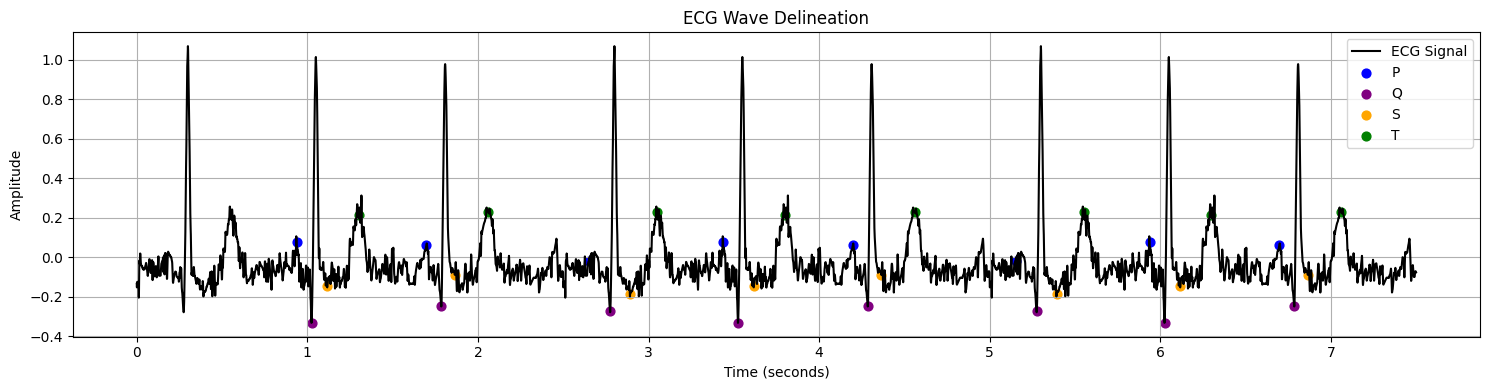

In [257]:
plot_ecg_waves(signal, result)

### 修正する

In [258]:
def detect_ecg_waves(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からP波・QRS波・T波のピーク位置を検出する関数

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 構成波のピーク位置（各波ごとにnp.ndarray）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values

    # 構成波検出
    _, waves = nk.ecg_delineate(signal, rpeaks=rpeaks, sampling_rate=fs, method="dwt")

    # 各波のピーク位置を抽出
    wave_peaks = {}
    for wave in ["ECG_P_Peaks", "ECG_Q_Peaks", "ECG_R_Peaks", "ECG_S_Peaks", "ECG_T_Peaks"]:
        wave_peaks[wave] = pd.Series(waves.get(wave, [])).dropna().astype(int).values

    return wave_peaks

In [210]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
#無理やり結合
signal =np.tile(signal, 3)

result = detect_ecg_waves_fixed(signal, fs=1000)
result

警告: Delineationの出力Rピークが空です。元のRピーク (18個) で結果を修正します。


{'ECG_P_Peaks': array([ 253,  546,  874, 1251, 1698, 2395, 2685, 3222, 3492, 3751, 4199,
        4460, 4921, 5254, 5524, 5936, 6251, 6699]),
 'ECG_Q_Peaks': array([ 275,  626,  932, 1310, 1785, 2431, 2757, 3290, 3524, 3853, 4285,
        4564, 5012, 5275, 5598, 6024, 6310, 6785]),
 'ECG_R_Peaks': array([ 322,  637,  952, 1322, 1806, 2469, 2773, 3294, 3603, 3862, 4306,
        4569, 5016, 5322, 5606, 6052, 6329, 6806]),
 'ECG_S_Peaks': array([ 350,  646,  966, 1326, 1864, 2470, 2891, 3314, 3608, 3876, 4364,
        4582, 5017, 5350, 5626, 6117, 6353, 6864]),
 'ECG_T_Peaks': array([ 453,  702, 1050, 1392, 1959, 2574, 2929, 3374, 3680, 3958, 4460,
        4679, 5125, 5454, 5703, 6145, 6458, 6960])}

In [212]:
### plotが明らかにおかしい、

In [259]:
# plotを行う関数
def plot_ecg_waves(signal: np.ndarray, wave_peaks: dict, fs: int = 1000, title: str = "ECG Wave Delineation"):
    """
    ECG波形と構成波（P, Q, R, S, T）を色分けして可視化する関数

    Parameters:
        signal (np.ndarray): ECG波形
        wave_peaks (dict): detect_ecg_waves() の出力
        fs (int): サンプリング周波数（Hz）
        title (str): プロットタイトル
    """
    time_axis = np.arange(len(signal)) / fs
    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, signal, label="ECG Signal", color="black")

    wave_colors = {
        "ECG_P_Peaks": "blue",
        "ECG_Q_Peaks": "purple",
        "ECG_R_Peaks": "red",
        "ECG_S_Peaks": "orange",
        "ECG_T_Peaks": "green"
    }

    for wave, color in wave_colors.items():
        peaks = wave_peaks.get(wave, [])
        if isinstance(peaks, (np.ndarray, list)) and len(peaks) > 0:
            plt.scatter(time_axis[peaks], signal[peaks], color=color,
                        label=wave.replace("ECG_", "").replace("_Peaks", ""), s=40)

    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

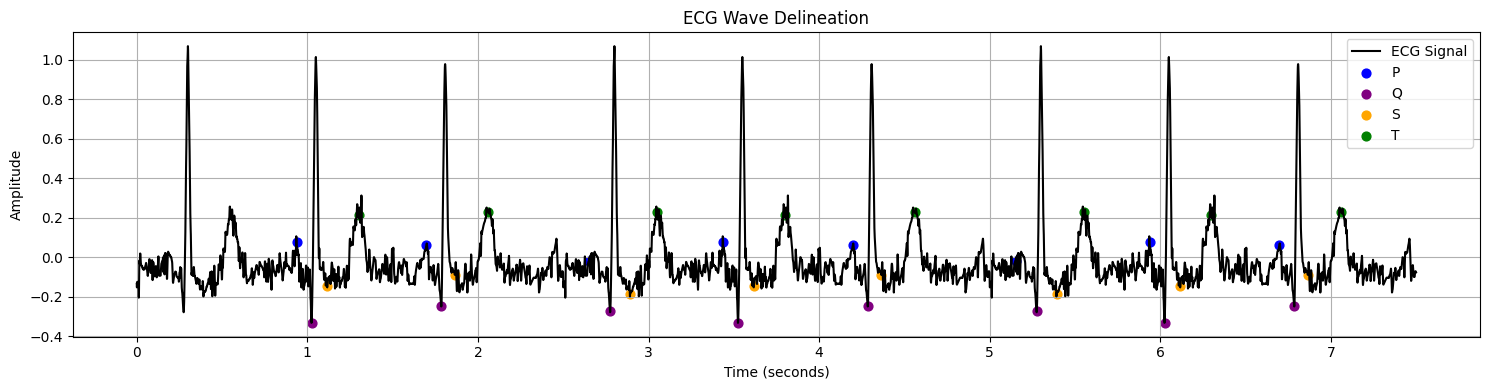

In [260]:
plot_ecg_waves(signal, result)

In [282]:
### 上記だとRーpeakのみ欠落する

### neurokitにある平滑化

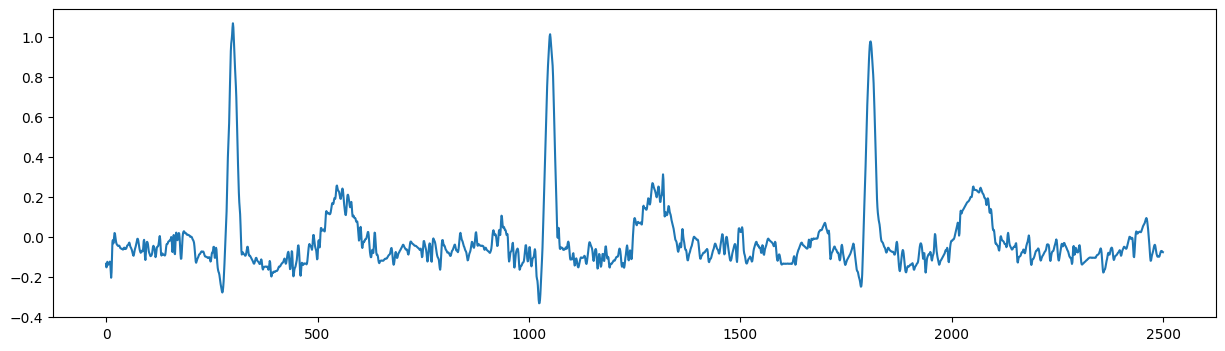

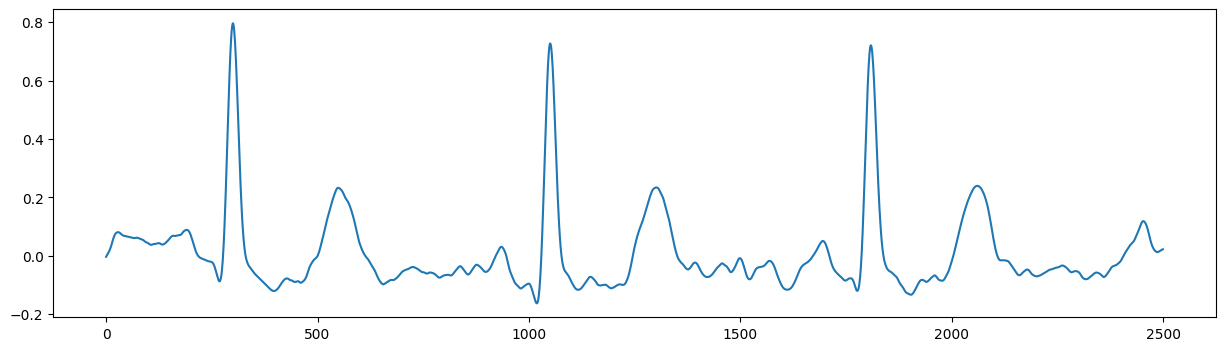

In [262]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
signal = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()

In [263]:
# 平滑化をかけた後での検出

In [264]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")
#平滑化
fs =1000
signal = nk.ecg_clean(signal, sampling_rate=fs, method="neurokit")
#無理やり結合
signal =np.tile(signal, 3)

result = detect_ecg_waves(signal, fs=1000)
result

{'ECG_P_Peaks': array([ 934, 1694, 2689, 3434, 4194, 5189, 5934, 6694]),
 'ECG_Q_Peaks': array([1020, 1777, 2769, 3520, 4277, 5269, 6020, 6777]),
 'ECG_R_Peaks': array([], dtype=int64),
 'ECG_S_Peaks': array([1117, 1904, 2898, 3617, 4404, 5398, 6117, 6904]),
 'ECG_T_Peaks': array([1300, 2059, 3051, 3800, 4560, 5551, 6300, 7060])}

### scipyを使用したもの

1. 🎛️ SciPyを使用した標準的なデジタルフィルタリング


PythonのSciPyライブラリは、フィルタ設計の標準的なツールです。ノイズの周波数帯域が明確な場合に、フィルタの特性（カットオフ周波数、次数）を細かく制御できます。

A. ベースラインドリフト除去 (ハイパスフィルタ)
低周波のベースライン変動を除去します。

In [265]:

from scipy.signal import butter, lfilter

def highpass_filter(signal: np.ndarray, cutoff_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """ハイパスフィルタ（バターワース）を適用し、ベースラインドリフトを除去する"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff_hz / nyq
    
    # バターワースフィルタの係数を設計
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    
    # 信号にフィルタを適用 (双方向フィルタリングで位相歪みを回避)
    # lfilterの代わりにfiltfiltを使う方が、位相遅延を防げてECG解析では望ましい
    filtered_signal = lfilter(b, a, signal)
    
    return filtered_signal

# 使用例: 0.5 Hz以下の低周波ノイズを除去
# signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)

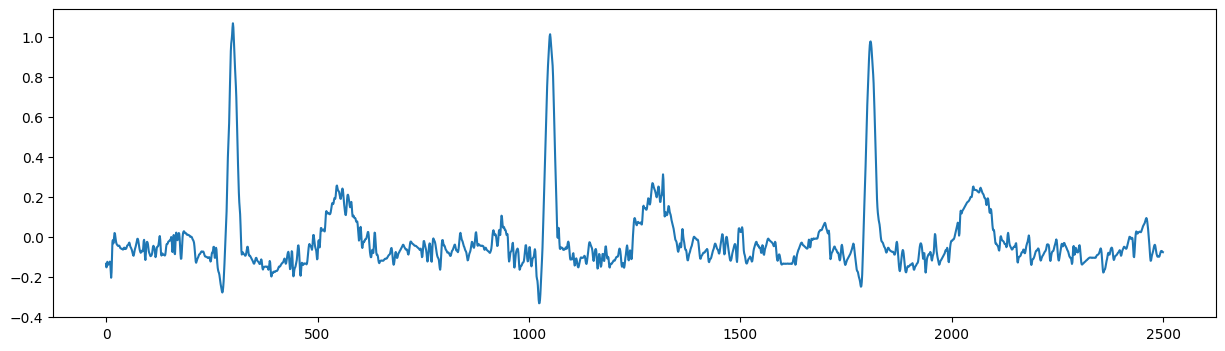

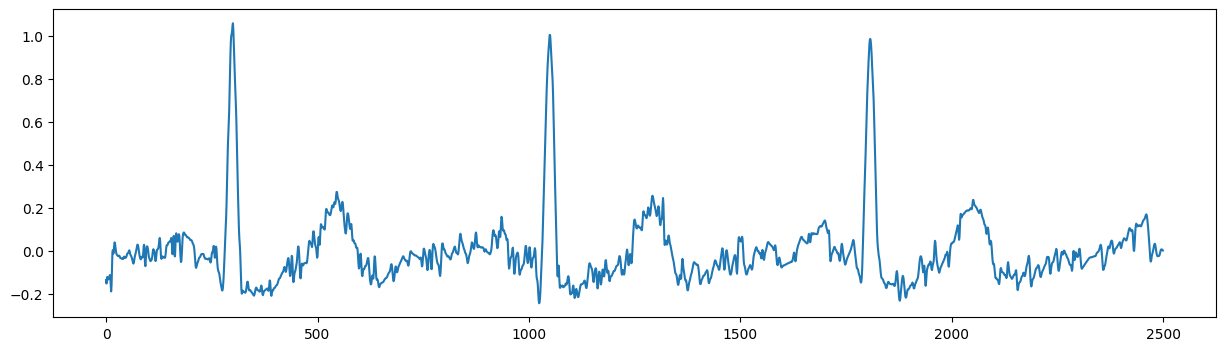

In [267]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()
signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)
plt.figure(figsize=(15, 4))
plt.plot(signal_filtered)
plt.show()

B. 高周波ノイズ除去 (ローパスフィルタ)

- 筋電図ノイズなどの高周波成分を除去し、波形を滑らかにします。

In [269]:
from scipy.signal import butter, lfilter

def lowpass_filter(signal: np.ndarray, cutoff_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """ローパスフィルタ（バターワース）を適用し、高周波ノイズを除去する"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff_hz / nyq
    
    # バターワースフィルタの係数を設計
    b, a = butter(order, normal_cutoff, btype='low', analog=False)
    
    # 信号にフィルタを適用 (双方向フィルタリングで位相歪みを回避)
    filtered_signal = lfilter(b, a, signal)
    
    return filtered_signal

# 使用例: 40 Hz以上の高周波ノイズを除去 (ECGでは一般的に使われるカットオフ)
# signal_smoothed = lowpass_filter(signal, cutoff_hz=40.0, fs=1000)

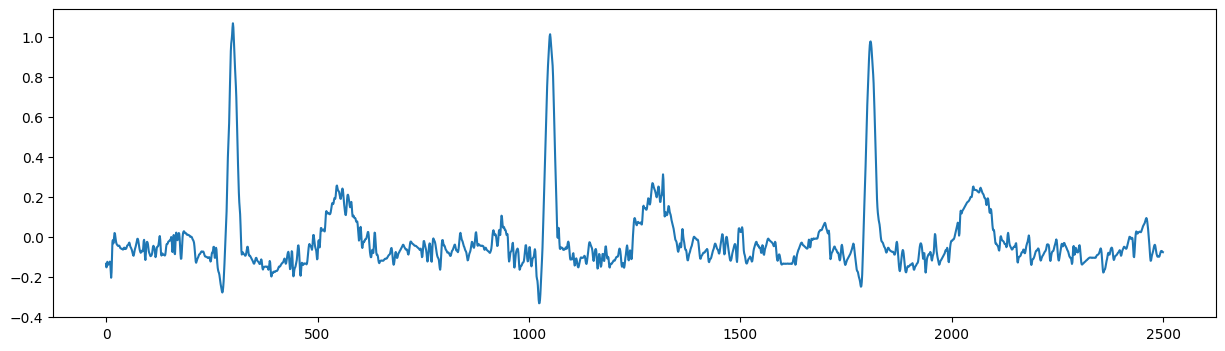

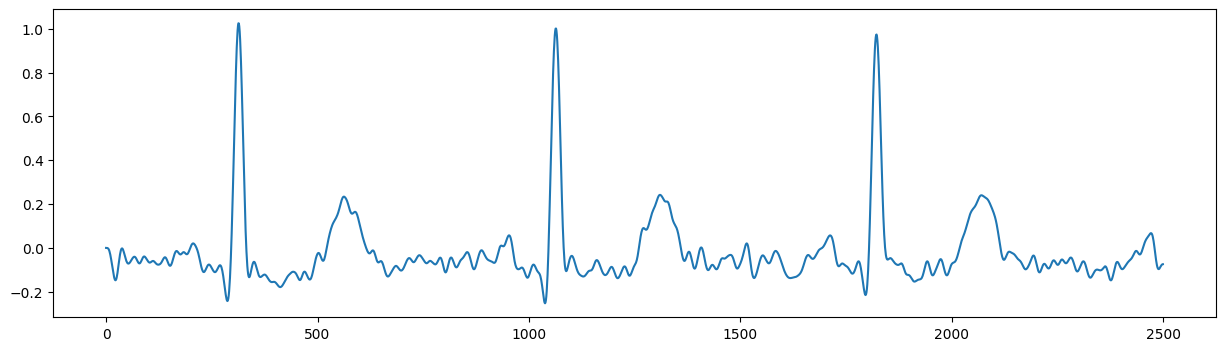

In [270]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()
#signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)
signal_smoothed = lowpass_filter(signal, cutoff_hz=40.0, fs=1000)
plt.figure(figsize=(15, 4))
plt.plot(signal_smoothed)
plt.show()

2. 🌊 ウェーブレット変換によるノイズ除去 (Denoising)

ウェーブレット変換は、時間と周波数の両方で信号を分析できるため、ノイズと信号成分を効果的に分離できます。これは特にP波やT波の微妙な形状を保持しつつノイズを除去したい場合に有効です。

ライブラリ: PyWavelets (pywt) が一般的に使われます。

In [271]:
import pywt

def wavelet_denoise(signal: np.ndarray, wavelet: str = 'db4', level: int = 3) -> np.ndarray:
    """ウェーブレット変換によるノイズ除去（平滑化）"""
    
    # ウェーブレット変換を実行
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    
    # 各レベルのノイズ閾値を計算（通常、中央値絶対偏差MADを使用）
    sigma = pywt.median_absolute_deviation(coeffs[-level])
    threshold = sigma * np.sqrt(2 * np.log(len(signal)))
    
    # ノイズ成分（詳細係数）に閾値処理を適用
    denoised_coeffs = []
    for i, coeff in enumerate(coeffs):
        if i == 0:
            # 近似係数はそのまま残す（低周波の信号成分）
            denoised_coeffs.append(coeff)
        else:
            # 詳細係数にソフト閾値処理を適用
            denoised_coeffs.append(pywt.threshold(coeff, threshold, mode='soft'))
            
    # 逆ウェーブレット変換で信号を再構成
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)
    
    # NOTE: 長さが少し変わる場合があるため、元の長さに合わせてクリップまたはパディングが必要な場合がある
    return denoised_signal[:len(signal)]

# ウェーブレットノイズ除去は、実装が複雑になるため、nk.ecg_cleanが失敗する場合の高度な代替策として検討します。

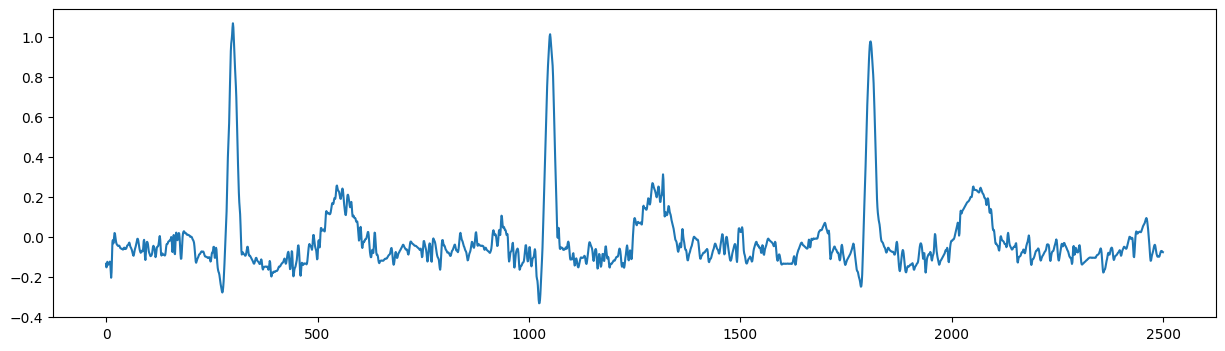

AttributeError: module 'pywt' has no attribute 'median_absolute_deviation'

In [272]:
signal = extract_lead_signal(ecg_df, lead="I")
plt.figure(figsize=(15, 4))
plt.plot(signal)
plt.show()
#signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)
signal_smoothed = wavelet_denoise(signal)
plt.figure(figsize=(15, 4))
plt.plot(signal_smoothed)
plt.show()

In [273]:
import numpy as np
from scipy.signal import butter, filtfilt
import pywt
from typing import Tuple

# --- SciPyによる標準的なデジタルフィルタリング（ECG解析推奨） ---

def butter_bandpass_filter(signal: np.ndarray, lowcut_hz: float, highcut_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """
    ECG信号にバターワース・バンドパスフィルタを適用し、ノイズとベースラインを除去する。
    
    Parameters:
        signal (np.ndarray): 処理対象の信号。
        lowcut_hz (float): ハイパスフィルタのカットオフ周波数（ベースライン除去）。通常 0.5 Hz。
        highcut_hz (float): ローパスフィルタのカットオフ周波数（高周波ノイズ除去）。通常 30-40 Hz。
        fs (int): サンプリング周波数（Hz）。
        order (int): フィルタの次数。

    Returns:
        np.ndarray: フィルタリングされた信号。
    """
    if fs <= highcut_hz * 2:
        print("警告: サンプリング周波数が低すぎます。フィルタリングスキップ。")
        return signal.copy()

    nyq = 0.5 * fs
    low = lowcut_hz / nyq
    high = highcut_hz / nyq
    
    # バンドパスフィルタの係数を設計
    b, a = butter(order, [low, high], btype='band', analog=False)
    
    # filtfiltを使用し、位相遅延のないフィルタリングを実行
    # NOTE: filtfiltを使用する場合、信号が短すぎるとエラーになる可能性があるため、信号長をチェック
    if len(signal) < 3 * order:
        raise ValueError(f"信号が短すぎます。filtfiltを使用するには信号長が {3*order} サンプル以上必要です。")
        
    filtered_signal = filtfilt(b, a, signal)
    
    return filtered_signal

# --- PyWaveletsによるウェーブレットノイズ除去（修正版） ---

def wavelet_denoise(signal: np.ndarray, wavelet: str = 'db4', level: int = 3) -> np.ndarray:
    """
    ウェーブレット変換によるノイズ除去（平滑化）。
    median_absolute_deviationのエラーに対応するため、NumPyでMADを計算するように修正済み。

    Parameters:
        signal (np.ndarray): 処理対象の信号。
        wavelet (str): 使用するウェーブレットファミリー。
        level (int): 分解レベル。

    Returns:
        np.ndarray: ノイズ除去された信号。
    """
    
    # 信号の長さが2のべき乗でない場合があるため、処理
    coeffs = pywt.wavedec(signal, wavelet, level=level)
    
    # ノイズレベルの推定（MAD法：最も細かいスケール(coeffs[-1])の絶対値の中央値を使用）
    # 0.6745 は正規分布における定数で、標準偏差の推定に使用
    noise_estimate = np.median(np.abs(coeffs[-1])) / 0.6745
    
    # VisuShrink閾値を計算 (普遍的閾値)
    threshold = noise_estimate * np.sqrt(2 * np.log(len(signal)))
    
    denoised_coeffs = []
    for i, coeff in enumerate(coeffs):
        if i == 0:
            # 近似係数はそのまま残す
            denoised_coeffs.append(coeff)
        else:
            # 詳細係数にソフト閾値処理を適用
            denoised_coeffs.append(pywt.threshold(coeff, threshold, mode='soft'))
            
    # 逆ウェーブレット変換で信号を再構成
    denoised_signal = pywt.waverec(denoised_coeffs, wavelet)[:len(signal)]
    
    return denoised_signal



In [274]:
# --- 使用例 ---
if __name__ == '__main__':
    fs = 1000
    #t = np.linspace(0, 5, 5*fs, endpoint=False)
    # ノイズとドリフトを含むモック信号
    #ecg_signal = np.sin(2 * np.pi * 1 * t) + np.random.normal(0, 0.2, 5000) + np.sin(2 * np.pi * 0.1 * t) * 0.5
    ecg_signal = extract_lead_signal(ecg_df, lead="I")
    print("--- フィルタリングテスト ---")

    # 1. SciPyによるバンドパスフィルタ（推奨）
    try:
        # ベースライン除去(0.5Hz以下)と高周波ノイズ除去(40Hz以上)を同時に実行
        scipy_filtered = butter_bandpass_filter(ecg_signal, lowcut_hz=0.5, highcut_hz=40.0, fs=fs)
        print("SciPy (Bandpass) フィルタリング成功。")
    except Exception as e:
        print(f"SciPyフィルタリングエラー: {e}")
        scipy_filtered = ecg_signal
        
    # 2. ウェーブレットノイズ除去（修正版）
    try:
        wavelet_filtered = wavelet_denoise(ecg_signal, wavelet='db4', level=4)
        print("Waveletノイズ除去成功。")
    except Exception as e:
        print(f"Waveletノイズ除去エラー: {e}")
        wavelet_filtered = ecg_signal
        
    print("フィルタリングされた信号が生成されました。これを次のステップ（safe_tile_signalなど）に使用できます。")

--- フィルタリングテスト ---
SciPy (Bandpass) フィルタリング成功。
Waveletノイズ除去成功。
フィルタリングされた信号が生成されました。これを次のステップ（safe_tile_signalなど）に使用できます。


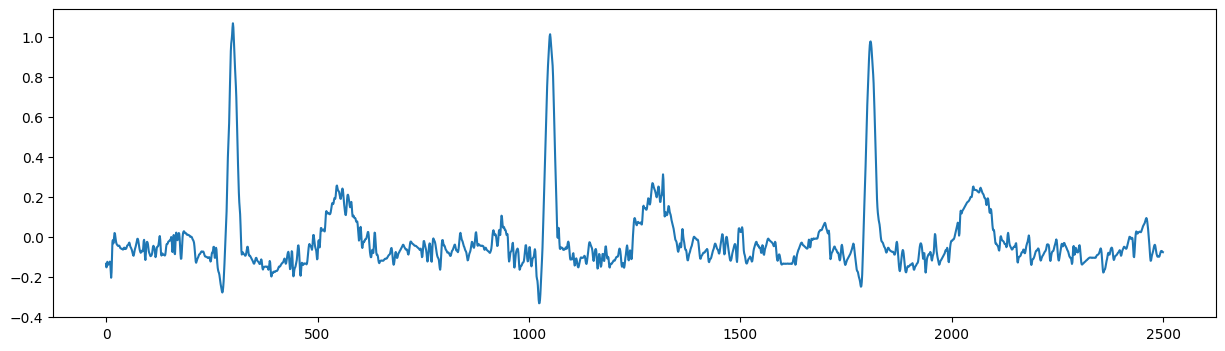

In [275]:
plt.figure(figsize=(15, 4)) 
plt.plot(ecg_signal)
plt.show()

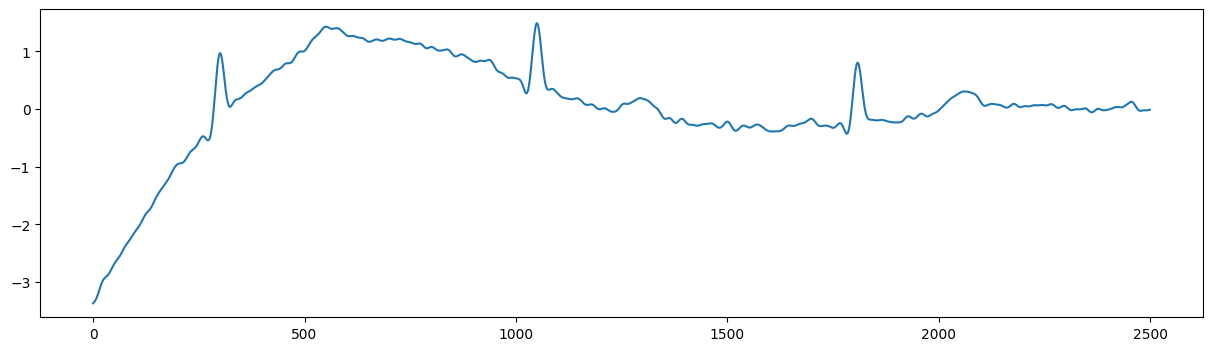

In [276]:
plt.figure(figsize=(15, 4)) 
plt.plot(scipy_filtered)

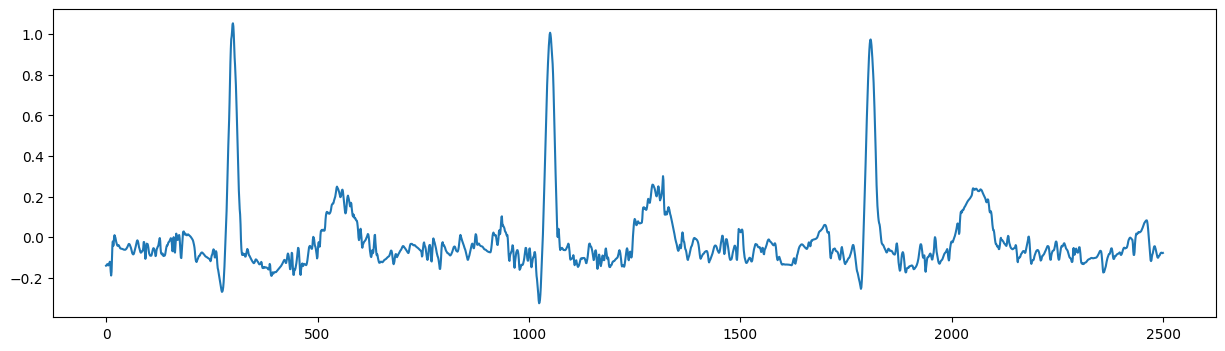

In [277]:
plt.figure(figsize=(15, 4)) 
plt.plot(wavelet_filtered)

### scipy filteringでの急激な立ち上がりについて

この問題は、ゼロ位相フィルタリング（scipy.signal.filtfilt）を使用した際に発生する**初期過渡応答（Start-up Transient）**と呼ばれる現象です。

🚨 Rピーク検出における初期過渡応答の問題点
filtfiltは、信号の位相をずらさずにフィルタリングするために順方向と逆方向に2回フィルタをかけますが、信号の最初と最後ではフィルタの初期条件が不安定になり、一時的に信号がオーバーシュートしたり急激に立ち上がったりします。

特にECGのベースライン除去（低周波カット）のようなフィルタでは、信号の最初の部分がフィルタの定常状態に達するまで時間がかかるため、このトランジェントが目立ちます。

💡 解決策：初期トランジェントの抑制と安定化
解決策は、「トランジェントを無視できるほど短くする」か、「信号の開始部分でトランジェントが発生しないようにパディングを工夫する」の2つです。

最も実用的な解決策として、以下の手法を提案します。

SOSフィルタリングの使用: filtfiltの代わりに、数値的に安定性が高いscipy.signal.sosfiltfiltを使用します。

パディングの強化: filtfilt系関数が内部で行うパディングを強化し、トランジェントを信号の先頭から押し出します。

以下の関数では、安定性の高いsosfiltfiltと、フィルタの次数に基づいて推奨されるパディング長（padlen=3*order）を適用します。

In [278]:
import numpy as np
from scipy.signal import butter, sosfiltfilt
from typing import Tuple

def butter_bandpass_filter(signal: np.ndarray, lowcut_hz: float, highcut_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """
    ECG信号にバターワース・バンドパスフィルタを適用する。
    scipy.signal.sosfiltfiltを使用することで、数値的安定性と初期トランジェントへの対応力を向上させる。

    Parameters:
        signal (np.ndarray): 処理対象の信号。
        lowcut_hz (float): ハイパスフィルタのカットオフ周波数（ベースライン除去）。通常 0.5 Hz。
        highcut_hz (float): ローパスフィルタのカットオフ周波数（高周波ノイズ除去）。通常 30-40 Hz。
        fs (int): サンプリング周波数（Hz）。
        order (int): フィルタの次数。

    Returns:
        np.ndarray: フィルタリングされた信号。
    """
    if fs <= highcut_hz * 2:
        print("警告: サンプリング周波数が低すぎます。フィルタリングスキップ。")
        return signal.copy()

    nyq = 0.5 * fs
    low = lowcut_hz / nyq
    high = highcut_hz / nyq
    
    # バターワースフィルタのセカンドオーダセクション（SOS）係数を設計
    # sosfiltfiltは、b, a係数ではなくsos係数を使用することで、数値的な丸め誤差を防ぐため推奨される
    sos = butter(order, [low, high], btype='band', analog=False, output='sos')
    
    # sosfiltfiltを使用し、位相遅延のないフィルタリングを実行
    # padlen='auto' (推奨) または padlen=3*order を使用して、トランジェントを抑制する
    
    # filtfilt系関数は信号長がパッド長*3未満だとエラーになる
    min_len = 3 * order
    if len(signal) < min_len:
        raise ValueError(f"信号が短すぎます。フィルタリングには最低 {min_len} サンプルが必要です。")
        
    # sosfiltfiltのpadtype='odd'はデフォルトで反射パディングを行い、トランジェント抑制を試みる
    filtered_signal = sosfiltfilt(sos, signal, padtype='odd', padlen=min_len)
    
    return filtered_signal

In [279]:
# ベースライン除去(0.5Hz以下)と高周波ノイズ除去(40Hz以上)を同時に実行
scipy_filtered = butter_bandpass_filter(ecg_signal, lowcut_hz=0.5, highcut_hz=40.0, fs=fs)
print("SciPy (Bandpass) フィルタリング成功。")

SciPy (Bandpass) フィルタリング成功。


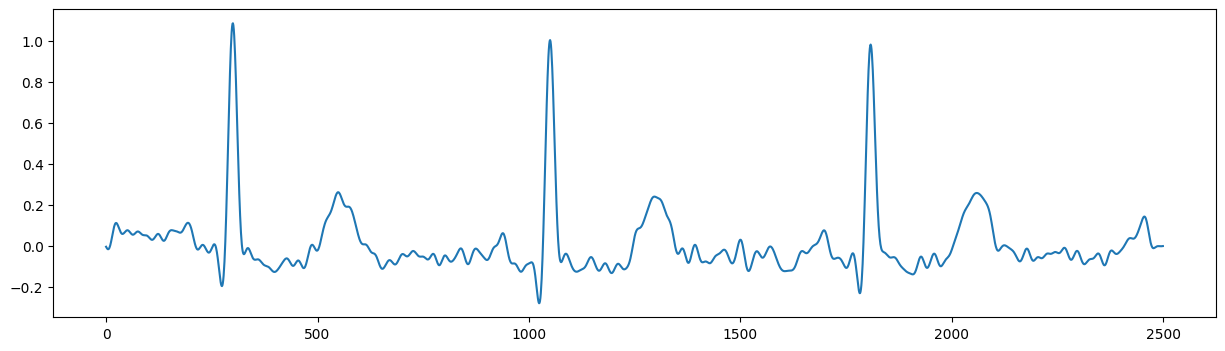

In [280]:
plt.figure(figsize=(15, 4)) 
plt.plot(scipy_filtered)

補足：それでも立ち上がりが気になる場合上記の修正版でトランジェントは改善されるはずですが、もしまだ最初の立ち上がりが急激すぎると感じる場合は、以下の方法を検討してください。信号のトリミング: フィルタリング後の信号の最初の数サンプルを物理的に削除します。ECG解析では、正確なピーク検出が必要なため、信号の最初から安定していることが理想です。フィルタの次数にもよりますが、最初の $3 \times \text{order}$ サンプルや、最初の 50ms（$0.05 \times \text{fs}$ サンプル）程度を無視して、残りの安定した部分のみを次のsafe_tile_signalに渡すことを検討してください。

In [ ]:
# 例：フィルタリング後の信号の最初の50サンプルを無視する
N_SKIP = int(0.05 * fs) 
stable_signal = scipy_filtered[N_SKIP:]

####

### 04.CSVのデータ処理について考える

### Import Packages

In [ ]:
import sys
import numpy as np
import pandas as pd
import pathlib
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import polars as pl
from pprint import pprint
import yaml
from tqdm import tqdm

# notebook上で.pyファイルを設定しなおして、リロードする場合
import importlib

#- sys.modules に一度読み込まれたモジュールは、再度 import してもキャッシュから取得されます。
#- importlib.reload() はそのキャッシュを明示的に更新する方法
# .pyファイルのリロードする場合
#importlib.reload(ecg_reader)

### Set Project Root Directory

In [ ]:
#config.yamlを配置したフォルダをルートフォルダと設定する
def find_project_root(marker: str = "config.yaml") -> Path:
    path = Path.cwd()
    while not (path / marker).exists() and path != path.parent:
        path = path.parent
    return path

project_root = find_project_root()
print("RootDirectory Path:",project_root)

# system Pathに追加
sys.path.append(str(project_root))
#pprint(sys.path)
#project_root = Path.cwd().parent で設定するとuserName/projectsがparaentsフォルダ賭して認識されるため上記方法で固定とする

### フォルダ構成の確認
directory_file_list = list(project_root.glob("*"))
pprint(directory_file_list)

RootDirectory Path: /Users/yohe/Desktop/ECG-Analysis
[PosixPath('/Users/yohe/Desktop/ECG-Analysis/analysis_test.ipynb'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/config.yaml'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/README.md'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/.git'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/MEMO.md'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/notebooks'),
 PosixPath('/Users/yohe/Desktop/ECG-Analysis/src')]


In [ ]:
from src.data_utils.ecg_reader import load_table_as_pandas, load_ecg_metadata_by_id, extract_lead_features, plot_ecg_waveform
from src.system_utils import detect_os, windows_to_wsl_path, check_config_paths
from src.config_loader import DataConfig

### Set Dataset Root Directory

In [ ]:
# OSを判定し、WSLの環境ではWindowsのディレクトリにアクセス可能なようにRootDirectoryを変更
detected_os = detect_os()
print("System Environment:", detected_os)

#wsl
#set_root_directory = r"C:\Users\yohei\Desktop\physionet-ecg-image-digitization"
#mac
set_root_directory = "/Users/yohe/Desktop/physionet-ecg-image-digitization"

if detected_os == "wsl":
    ECG_DATASET_ROOT = windows_to_wsl_path(set_root_directory)
else:
    ECG_DATASET_ROOT = Path(set_root_directory)

print("Project Root:", ECG_DATASET_ROOT)

System Environment: mac
Project Root: /Users/yohe/Desktop/physionet-ecg-image-digitization


### Set CONFIG

In [ ]:
# datareader用の設定
CONFIG = DataConfig(config_yaml_path=project_root/"config.yaml", 
                    root=ECG_DATASET_ROOT)
#CONFIGのパラメータを確認
pprint(CONFIG.__dict__)

# CONFIG内のパスが存在するか確認
check_config_paths(CONFIG)

{'sample_submission_csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/sample_submission.parquet'),
 'test_csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/test.csv'),
 'test_data_dir': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/test'),
 'train_csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train.csv'),
 'train_data_dir': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train')}
すべてのパスが存在します


### Read DataFrame

In [ ]:
train_df = load_table_as_pandas(path=CONFIG.train_csv_path, verbose=True)
test_df = load_table_as_pandas(path=CONFIG.test_csv_path, verbose=True)
sample_submission = load_table_as_pandas(path=CONFIG.sample_submission_csv_path, verbose=True)

Datatype is CSV
Datatype is CSV
Datatype is Parquet


### sample Data in Dataframe
- id
- fs :sampling frequency（サンプリング周波数）
- sig_len : signal length（信号長）<br>通常は1リードあたりのサンプル数。例：sig_len = 650000 なら 650,000点の波形


In [ ]:
print(train_df.info())
print("====================================")
sample_id = "7663343"

#DataSet directory
sample_data_dir = CONFIG.train_data_dir / sample_id
print("sample Dir Exist:",sample_data_dir.exists())

# datalist
sample_data_path_list = list(sample_data_dir.glob("*"))
pprint(sample_data_path_list)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 977 entries, 0 to 976
Data columns (total 3 columns):
 #   Column   Non-Null Count  Dtype
---  ------   --------------  -----
 0   id       977 non-null    int64
 1   fs       977 non-null    int64
 2   sig_len  977 non-null    int64
dtypes: int64(3)
memory usage: 23.0 KB
None
sample Dir Exist: True
[PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/7663343/7663343.csv'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0001.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0003.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0012.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0006.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/7663343/7663343-0010.png'),
 PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitiza

### データリークを防ぐ構造を持たせる。

In [ ]:
def enrich_df_with_png_and_csv(df:pd.DataFrame, base_dir:pathlib.Path) -> pd.DataFrame :
    '''
    dataFrameにpngおよびcsvのパスを追加する処理
    '''
    df = df.copy()
    data_dirs = []
    png_paths = []
    ecg_csv_paths = []

    for sample_id in tqdm(df["id"]):
        sample_dir = base_dir / str(sample_id)
        if not sample_dir.exists():
            print(f"Warning: Directory not found for ID {sample_id}")
        data_dirs.append(sample_dir)

        # PNG群
        pngs = sorted(sample_dir.glob("*.png"))
        png_paths.append(pngs)

        # CSVファイル（1つだけ想定）
        csv_files = sorted(sample_dir.glob("*.csv"))
        if len(csv_files) > 1:
            print(f"Warning: Multiple CSVs found for ID {sample_id}")
        ecg_csv_path = csv_files[0] if csv_files else None
        ecg_csv_paths.append(ecg_csv_path)

    df["data_directory"] = data_dirs
    df["png_image_paths"] = png_paths
    df["ecg_csv_path"] = ecg_csv_paths
    return df

In [ ]:
train_df_withPath = enrich_df_with_png_and_csv(train_df, CONFIG.train_data_dir)

train_df_withPath.info()

# sampleデータPLOT
sample_id = 11842146
row = train_df_withPath[train_df_withPath["id"] == sample_id].iloc[0]

print("Directory:", row["data_directory"])
print("PNG files:")
for p in row["png_image_paths"]:
    print(" -", p)

100%|██████████| 977/977 [00:00<00:00, 18396.48it/s]

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 977 entries, 0 to 976
Data columns (total 6 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   id               977 non-null    int64 
 1   fs               977 non-null    int64 
 2   sig_len          977 non-null    int64 
 3   data_directory   977 non-null    object
 4   png_image_paths  977 non-null    object
 5   ecg_csv_path     977 non-null    object
dtypes: int64(3), object(3)
memory usage: 45.9+ KB
Directory: /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146
PNG files:
 - /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0001.png
 - /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0003.png
 - /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0004.png
 - /Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0005.png
 - /Users/yohe/Desktop/physionet-ecg-im

### samplePLOT

In [ ]:
sample_id = 11842146
sample_ecg_data_dict =load_ecg_metadata_by_id(ecg_id=sample_id, train_df=train_df_withPath)
sample_ecg_data_dict

{'id': '11842146',
 'fs': 1000.0,
 'sig_len': 10000,
 'duration_sec': 10.0,
 'csv_path': PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146.csv'),
 'png_image_paths': [PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0001.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0003.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0004.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0005.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0006.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0009.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0010.png'),
  PosixPath('/Users/yohe/Desktop/physionet-ecg-image-digitization/train/11842146/11

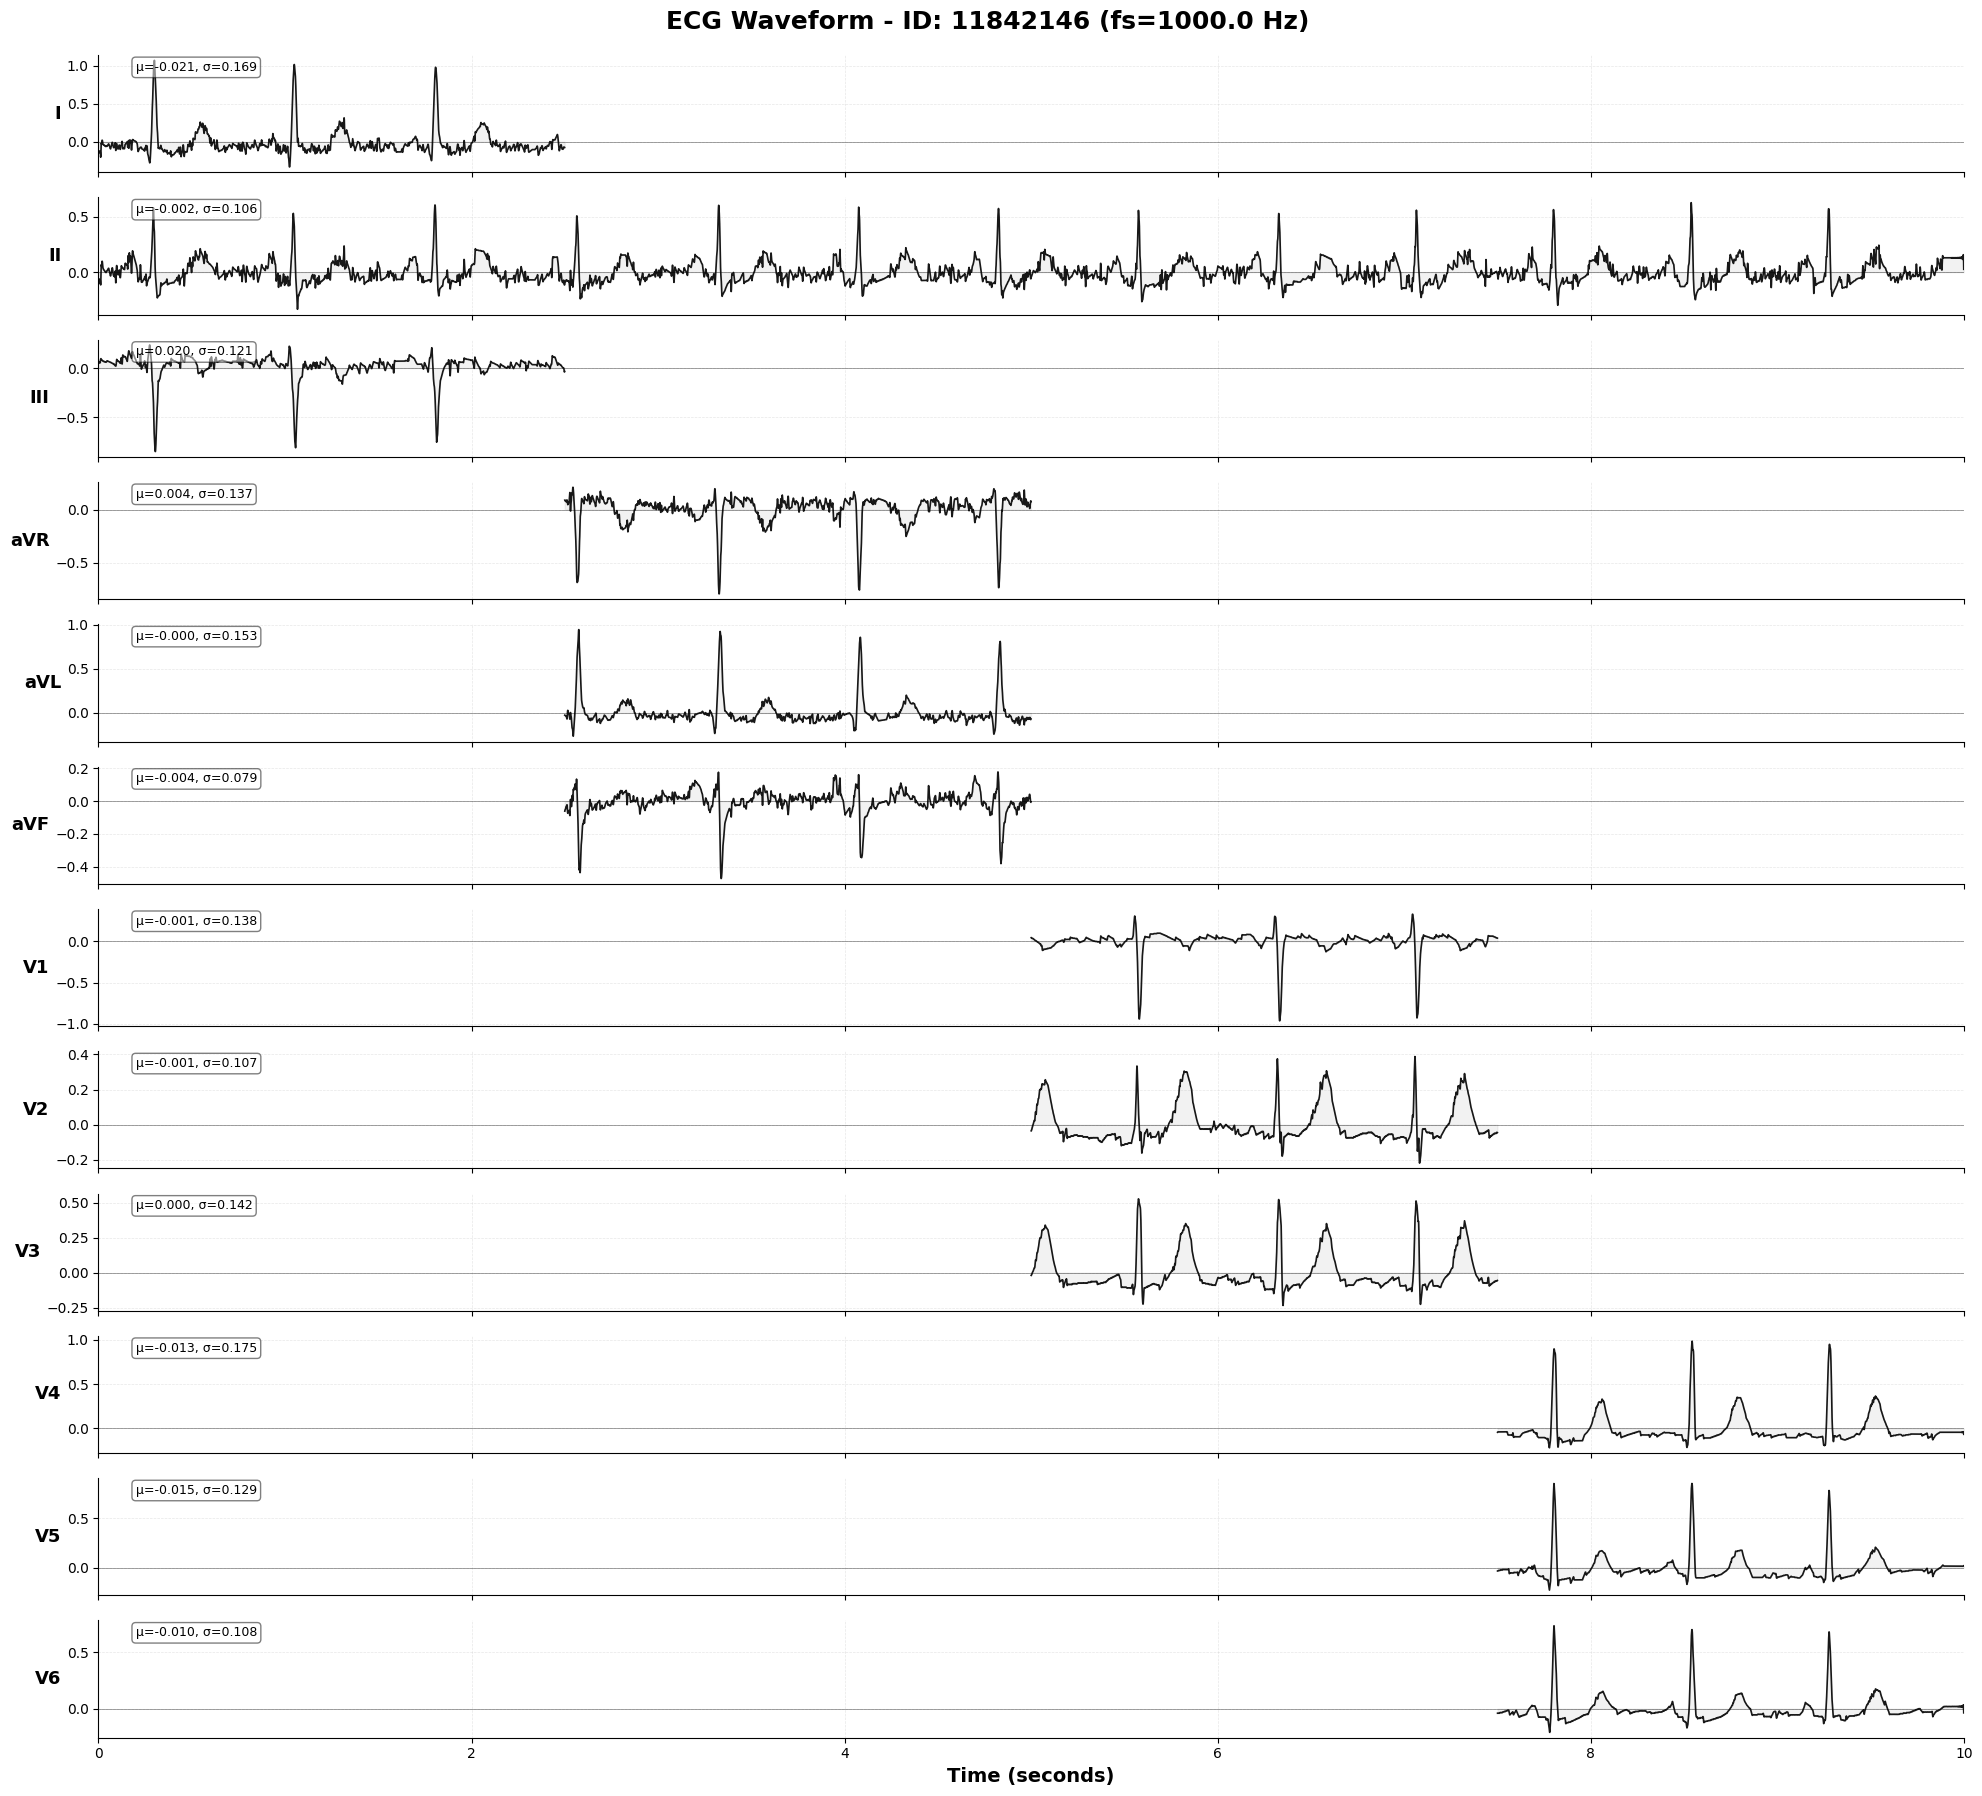

In [ ]:
temp_data = extract_lead_features(sample_ecg_data_dict)
plot_ecg_waveform(temp_data , ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                 'V1', 'V2', 'V3', 'V4', 'V5', 'V6'])

### DATALOADER : Labelデータなし

In [ ]:
import torch
from torch.utils.data import Dataset
from PIL import Image
import pandas as pd
import random
from torch.utils.data import DataLoader
from torchvision import transforms

: 

In [ ]:
class ECGImageDataset(Dataset):
    def __init__(self, df: pd.DataFrame, image_selector="first", transform=None)->dict:
        """
        image_selector: "first", "random", or callable
        transform: torchvision transforms or custom preprocessing
        """
        self.df = df.reset_index(drop=True)
        self.image_selector = image_selector
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def select_image(self, image_paths):
        if not image_paths:
            return None
        if self.image_selector == "first":
            return image_paths[0]
        elif self.image_selector == "random":
            return random.choice(image_paths)
        elif callable(self.image_selector):
            return self.image_selector(image_paths)
        else:
            raise ValueError(f"Invalid image_selector: {self.image_selector}")

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_paths = row["png_image_paths"]
        image_path = self.select_image(image_paths)
    
        if image_path is None or not image_path.exists():
            raise FileNotFoundError(f"Image not found for ID {row['id']}")
    
        image = Image.open(image_path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        
        #label が存在しない場合は -1 や 0 などのダミー値を返す
        #dict.get(key, default) の意味
        #- key が辞書に存在すれば → その値を返す
        #- key が存在しなければ → default を返す
        label = row.get("label", -1)
        label = torch.tensor(label, dtype=torch.long)
    
        return {
            "id": row["id"],
            "image": image,
            "label": label
        }
    

### ここ修正中！！！！
CSVの構成上あったりなかったりするから調整が大変そう。
どうする？？？

In [ ]:
from torchvision import transforms

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

dataset = ECGImageDataset(train_df_withPath, image_selector="random", transform=transform)
sample = dataset[0]
print("ID:", sample["id"])
print("Image shape:", sample["image"].shape)
print("Label:", sample["label"])

ID: 7663343
Image shape: torch.Size([3, 224, 224])
Label: tensor(-1)


In [ ]:
from torch.utils.data import DataLoader
from torchvision import transforms

# 画像前処理（例：リサイズ＋Tensor化）
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor()
])

# Datasetのインスタンス化（画像1枚選択、ランダム）
dataset = ECGImageDataset(
    df=train_df_withPath,
    image_selector="random",  # "first" でもOK
    transform=transform
)

# DataLoaderの作成（バッチサイズ1）
dataloader = DataLoader(
    dataset,
    batch_size=3,
    shuffle=False,     # 必要に応じてTrueに
    num_workers=0      # Windows環境なら0が安全
)

In [ ]:
for batch in dataloader:
    print("ID:", batch["id"])
    print("Image shape:", batch["image"].shape)
    print("Label:", batch["label"])
    break  # 1バッチだけ確認


ID: tensor([ 7663343, 10140238, 11842146])
Image shape: torch.Size([3, 3, 224, 224])
Label: tensor([-1, -1, -1])


### CSVデータをいかに教師ラベルとして学習させるかがカギになりそうなので考える


In [ ]:
csv_data = pd.read_csv(row["ecg_csv_path"])
csv_data 

,I,II,III,aVR,aVL,aVF,V1,V2,V3,V4,V5,V6
0,-0.135,-0.075,0.059,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,-0.153,-0.102,0.050,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,-0.134,-0.075,0.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,-0.125,-0.060,0.065,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,-0.134,-0.074,0.060,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,NaN,0.114,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.048,0.015,0.011
9996,NaN,0.130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.045,0.014,0.019
9997,NaN,0.158,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.038,0.014,0.035
9998,NaN,0.130,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.045,0.014,0.019


In [ ]:
### 欠損がかなり多そう。
csv_data.isnull().sum()

I      7500
II        0
III    7500
aVR    7500
aVL    7500
aVF    7500
V1     7500
V2     7500
V3     7500
V4     7500
V5     7500
V6     7500
dtype: int64

### neurokitV2で検出できるような仕様を作成する

In [ ]:
import neurokit2 as nk

In [ ]:
### リードデータを抽出する
def extract_lead_signal(ecg_df: pd.DataFrame, lead: str = "I") -> np.ndarray:
    """
    指定されたリードの波形を抽出し、NaNを除去して返す。
    
    Parameters:
        ecg_df (pd.DataFrame): ECGの波形データ（CSV読み込み済み）
        lead (str): 抽出対象のリード名（例："I", "II", "V1"など）

    Returns:
        np.ndarray: NaN除去済みの波形データ
    """
    if lead not in ecg_df.columns:
        raise ValueError(f"リード '{lead}' は存在しません。利用可能なリード: {list(ecg_df.columns)}")

    signal = pd.to_numeric(ecg_df[lead], errors="coerce").dropna().values

    if len(signal) == 0:
        raise ValueError(f"リード '{lead}' に有効な波形データが存在しません。")

    return signal

処理を組み立てていく

In [ ]:
# sample ID
sample_id = 11842146
#該当のrow抽出
row = train_df_withPath[train_df_withPath["id"] == sample_id].iloc[0]

#構成を確認
print("Directory:", row["data_directory"])
print("CSV path:", row["ecg_csv_path"])
print("PNG files:")
for p in row["png_image_paths"]:
    print(" -", p)

Directory: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146
CSV path: /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146.csv
PNG files:
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0001.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0003.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0004.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0005.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0006.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0009.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0010.png
 - /mnt/c/Users/yohei/Desktop/physionet-ecg-image-digitization/train/11842146/11842146-0011.png
 - /mnt/c/Users/yohei/Desktop/physion

In [ ]:
ecg_df = pd.read_csv(row["ecg_csv_path"])
lead_signal = extract_lead_signal(ecg_df=ecg_df, lead="I")
print("信号長:", len(lead_signal))

信号長: 2500


In [ ]:
train_df[train_df["id"]==sample_id]

,id,fs,sig_len
2,11842146,1000,10000


### Neurokit2を用いた抽出

In [ ]:
import neurokit2 as nk
import pandas as pd
import numpy as np

def detect_ecg_waves(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からP波・QRS波・T波のピーク位置を検出する関数

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 構成波のピーク位置（各波ごとにnp.ndarray）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values

    # 構成波検出
    _, waves = nk.ecg_delineate(signal, rpeaks=rpeaks, sampling_rate=fs, method="dwt")

    # 各波のピーク位置を抽出
    wave_peaks = {}
    for wave in ["ECG_P_Peaks", "ECG_Q_Peaks", "ECG_R_Peaks", "ECG_S_Peaks", "ECG_T_Peaks"]:
        wave_peaks[wave] = pd.Series(waves.get(wave, [])).dropna().astype(int).values

    return wave_peaks

In [ ]:
def detect_valid_segments(ecg_df: pd.DataFrame, leads: list[str] = None, min_length: int = 1000) -> list[pd.DataFrame]:
    """
    指定リードに基づいて有効な連続セグメントを抽出する関数

    Parameters:
        ecg_df (pd.DataFrame): ECG波形データ
        leads (list[str]): 有効性判定に使うリード名（Noneなら全リード）
        min_length (int): 最低セグメント長（行数）

    Returns:
        list[pd.DataFrame]: 有効セグメントのリスト（時間軸保持）
    """
    if leads is None:
        leads = ecg_df.columns.tolist()

    # 指定リードに基づいてNaN判定
    valid_mask = ~ecg_df[leads].isna().any(axis=1)

    # 連続区間の抽出
    runs = (valid_mask != valid_mask.shift()).cumsum()
    segments = [group for _, group in ecg_df[valid_mask].groupby(runs) if len(group) >= min_length]

    return [seg.reset_index(drop=True) for seg in segments]

In [ ]:

def detect_r_peaks(signal: np.ndarray, fs: int = 1000) -> dict:
    """
    ECG波形からRピークを検出する関数（NeuroKit2使用）

    Parameters:
        signal (np.ndarray): NaN除去済みのECG波形
        fs (int): サンプリング周波数（Hz）

    Returns:
        dict: 以下のキーを含む辞書
            - "rpeaks": Rピーク位置（int型のnumpy配列）
            - "signals": NeuroKit2の信号構造
            - "info": Rピーク検出情報（辞書）
    """
    if len(signal) < 100:
        raise ValueError("信号が短すぎます。最低100サンプル以上必要です。")

    # Rピーク検出（NeuroKit2）
    signals, info = nk.ecg_peaks(signal, sampling_rate=fs)

    # Rピーク位置を整数型で抽出
    rpeaks = pd.Series(info["ECG_R_Peaks"]).dropna().astype(int).values

    return {
        "rpeaks": rpeaks,
        "signals": signals,
        "info": info
    }

In [ ]:
#- Rピーク数が 5 未満 → nk.ecg_delineate() は失敗
#- Rピーク間隔がすべて同じ → 周期性が強すぎて失敗
signal = extract_lead_signal(ecg_df, lead="I")

r_result = detect_r_peaks(signal, fs=1000)
rpeaks = r_result["rpeaks"]
print("Rピーク数:", len(rpeaks))
print("Rピーク間隔:", np.diff(rpeaks))


Rピーク数: 2
Rピーク間隔: [758]


Rピーク数: 14
{'ECG_P_Peaks': array([  937,  1698,  2651,  3437,  4198,  5151,  5937,  6698,  7652,
        8437,  9198, 10189, 10937, 11698]), 'ECG_Q_Peaks': array([ 1025,  1785,  2775,  3524,  4285,  5275,  6024,  6785,  7775,
        8524,  9285, 10275, 11024, 11785]), 'ECG_R_Peaks': array([], dtype=int64), 'ECG_S_Peaks': array([ 1118,  1866,  2892,  3618,  4365,  5392,  6118,  6865,  7892,
        8617,  9366, 10392, 11118, 11866]), 'ECG_T_Peaks': array([ 1300,  2060,  3050,  3800,  4560,  5550,  6300,  7060,  8050,
        8800,  9560, 10550, 11300, 12060])}


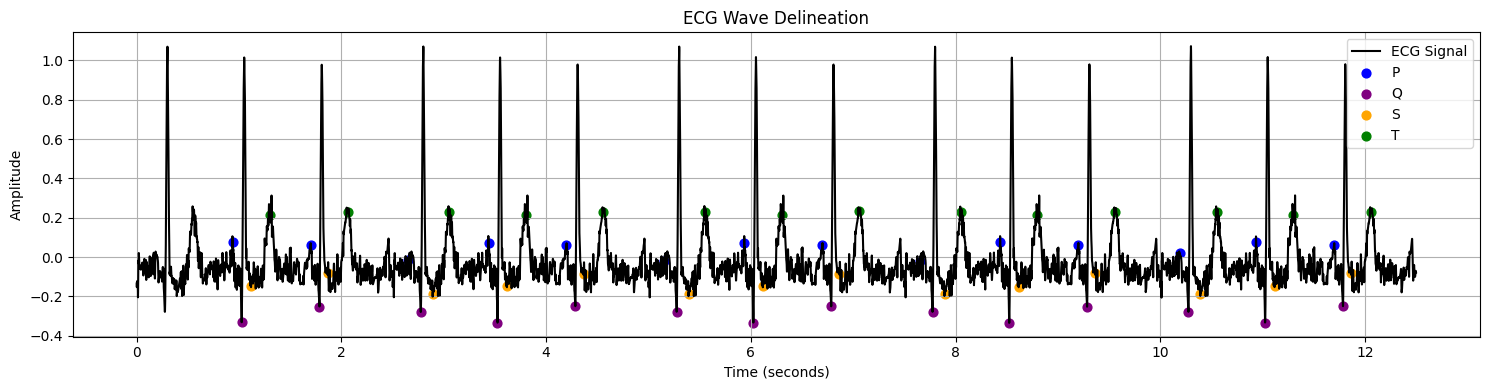

In [ ]:
# 微小ノイズを加えて周期性を崩す
signal = extract_lead_signal(ecg_df, lead="I")

np.random.seed(42)
signal = np.tile(signal, 5)
signal = signal + np.random.normal(0, 0.001, size=signal.shape)

# Rピーク検出
r_result = detect_r_peaks(signal, fs=1000)
rpeaks = r_result["rpeaks"]
print("Rピーク数:", len(rpeaks))

# Rピークが十分なら構成波検出
if len(rpeaks) >= 5:
    result = detect_ecg_waves(signal, fs=1000)
    print(result)
    plot_ecg_waves(signal, result, fs=1000)
else:
    print("Rピークが少なすぎて構成波検出できません")


In [ ]:
#短すぎるって出てしまいますね。
signal = extract_lead_signal(ecg_df, lead="I")
#短すぎるから拡張
#segments = detect_valid_segments(ecg_df, leads=["I"], min_length=300)
#signal = np.concatenate([extract_lead_signal(seg, lead="I") for seg in segments if len(seg) >= 300][:10])

signal = np.tile(signal, 5)

## 各点の検出
result = detect_ecg_waves(signal, fs=1000)
result

{'ECG_P_Peaks': array([  937,  1697,  2651,  3437,  4198,  5151,  5937,  6698,  7652,
         8437,  9198, 10152, 10937, 11698]),
 'ECG_Q_Peaks': array([ 1025,  1786,  2776,  3525,  4286,  5276,  6025,  6786,  7776,
         8525,  9286, 10276, 11025, 11786]),
 'ECG_R_Peaks': array([], dtype=int64),
 'ECG_S_Peaks': array([ 1118,  1865,  2892,  3618,  4365,  5392,  6118,  6865,  7892,
         8618,  9365, 10392, 11118, 11865]),
 'ECG_T_Peaks': array([ 1300,  2059,  3050,  3800,  4560,  5550,  6300,  7060,  8050,
         8800,  9560, 10550, 11300, 12060])}

In [ ]:
#segments = detect_valid_segments(ecg_df, leads=["I"], min_length=500)
#signal = np.concatenate([extract_lead_signal(seg, lead="I") for seg in segments[:3]])


In [ ]:
import matplotlib.pyplot as plt

def plot_ecg_waves(signal: np.ndarray, wave_peaks: dict, fs: int = 1000, title: str = "ECG Wave Delineation"):
    """
    ECG波形と構成波（P, Q, R, S, T）を色分けして可視化する関数

    Parameters:
        signal (np.ndarray): ECG波形
        wave_peaks (dict): detect_ecg_waves() の出力
        fs (int): サンプリング周波数（Hz）
        title (str): プロットタイトル
    """
    time_axis = np.arange(len(signal)) / fs
    plt.figure(figsize=(15, 4))
    plt.plot(time_axis, signal, label="ECG Signal", color="black")

    wave_colors = {
        "ECG_P_Peaks": "blue",
        "ECG_Q_Peaks": "purple",
        "ECG_R_Peaks": "red",
        "ECG_S_Peaks": "orange",
        "ECG_T_Peaks": "green"
    }

    for wave, color in wave_colors.items():
        peaks = wave_peaks.get(wave, [])
        if isinstance(peaks, (np.ndarray, list)) and len(peaks) > 0:
            plt.scatter(time_axis[peaks], signal[peaks], color=color,
                        label=wave.replace("ECG_", "").replace("_Peaks", ""), s=40)

    plt.title(title)
    plt.xlabel("Time (seconds)")
    plt.ylabel("Amplitude")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.show()

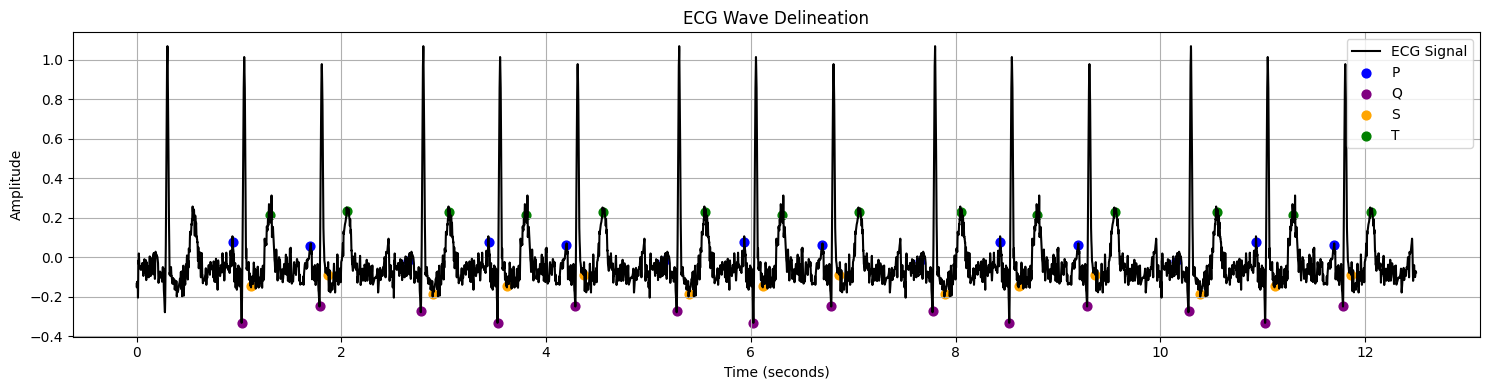

In [ ]:
plot_ecg_waves(signal, result)

### Rピークの検出エラーになっちゃうね。整理して進める

🔹 ② plot_ecg_segment(segment_df, fs, leads)
目的：抽出されたセグメントを時間軸付きで可視化
出力：matplotlib プロット
def plot_ecg_segment(segment_df: pd.DataFrame, fs: float, leads: list[str]):
    import matplotlib.pyplot as plt
    time_axis = np.arange(len(segment_df



In [ ]:
def plot_ecg_segment(segment_df: pd.DataFrame, fs: float, leads: list[str]):
    import matplotlib.pyplot as plt
    time_axis = np.arange(len(segment_df)) / fs
    fig, axes = plt.subplots(len(leads), 1, figsize=(20, 1.5 * len(leads)), sharex=True)
    if len(leads) == 1:
        axes = [axes]
    for ax, lead in zip(axes, leads):
        if lead in segment_df.columns:
            series = pd.to_numeric(segment_df[lead], errors="coerce")
            ax.plot(time_axis, series, color='black')
            ax.set_ylabel(lead)
    axes[-1].set_xlabel("Time (sec)")
    plt.tight_layout()
    plt.show()

🔹 ③ evaluate_segment_quality(segment_df)
目的：セグメントの品質を数値化（例：有効リード数、標準偏差、振幅範囲）
出力：dict 形式の評価指標


In [ ]:
def evaluate_segment_quality(segment_df: pd.DataFrame) -> dict:
    lead_stats = {}
    for lead in segment_df.columns:
        series = pd.to_numeric(segment_df[lead], errors="coerce").dropna()
        if len(series) > 0:
            lead_stats[lead] = {
                "std": series.std(),
                "range": series.max() - series.min(),
                "length": len(series)
            }
    return lead_stats

### 上記をまとめたもの

In [ ]:
def extract_and_plot_best_segment(ecg_df, fs, leads, min_length=1000):
    segments = detect_valid_segments(ecg_df, min_length)
    if not segments:
        print("No valid segment found.")
        return None

    # 評価して最も品質の高いセグメントを選択（例：stdの合計が最大）
    scored = [(seg, sum(v["std"] for v in evaluate_segment_quality(seg).values())) for seg in segments]
    best_segment = max(scored, key=lambda x: x[1])[0]

    plot_ecg_segment(best_segment, fs, leads)
    return best_segment

### DATASETの作成

In [ ]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class ECGWaveformDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config, lead_names=None):
        """
        Parameters:
        - meta_df: メタ情報を含むDataFrame（id, fs, sig_len, labelなど）
        - config: CONFIGクラス（train_data_dirなど）
        - lead_names: 使用するリード名（Noneなら全12誘導）
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.config = config
        self.lead_names = lead_names or ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                         'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        ecg_id = str(row["id"])

        # --- CSV読み込み ---
        csv_path = list((self.config.train_data_dir / ecg_id).glob("*.csv"))[0]
        ecg_df = pd.read_csv(csv_path)

        # --- リード抽出とTensor化 ---
        ecg_df = ecg_df[self.lead_names].astype(np.float32)
        ecg_array = ecg_df.to_numpy().T  # shape: (12, T)
        ecg_tensor = torch.from_numpy(ecg_array)  # NaNはそのまま保持

        # --- ラベル（任意） ---
        label = row.get("label", -1)

        return {
            "id": ecg_id,
            "ecg": ecg_tensor,  # shape: (12, T)
            "label": label
        }

In [ ]:
def ecg_collate_fn(batch):
    return {
        "id": [item["id"] for item in batch],
        "label": torch.tensor([item["label"] for item in batch], dtype=torch.long),
        "ecg": [item["ecg"] for item in batch]  # list of [12, T_i] tensors
    }


In [ ]:
from torch.utils.data import DataLoader

dataset = ECGWaveformDataset(meta_df=train_df, config=CONFIG)
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=ecg_collate_fn)
batch = next(iter(loader))
#print(batch["ecg"].shape)    # torch.Size([8, 12, T])
#print(batch["label"])        # torch.Size([8])
#print(batch["id"])           # list of 8 IDs

In [ ]:
batch

{'id': ['197560770',
  '3628654192',
  '500216573',
  '2334335621',
  '2172544932',
  '322694441',
  '740083255',
  '3615951423'],
 'label': tensor([-1, -1, -1, -1, -1, -1, -1, -1]),
 'ecg': [tensor([[-0.1450, -0.1650, -0.1440,  ...,     nan,     nan,     nan],
          [-0.0890, -0.0850, -0.0900,  ..., -0.1290, -0.1250, -0.1070],
          [ 0.0550,  0.0800,  0.0550,  ...,     nan,     nan,     nan],
          ...,
          [    nan,     nan,     nan,  ..., -0.1070, -0.0900, -0.0250],
          [    nan,     nan,     nan,  ..., -0.1560, -0.1350, -0.0570],
          [    nan,     nan,     nan,  ...,  0.0550,  0.0400, -0.0150]]),
  tensor([[-0.1140, -0.1370, -0.1150,  ...,     nan,     nan,     nan],
          [-0.0400, -0.0390, -0.0390,  ..., -0.0450, -0.0450, -0.0420],
          [ 0.0750,  0.0980,  0.0750,  ...,     nan,     nan,     nan],
          ...,
          [    nan,     nan,     nan,  ...,  0.3050,  0.2490,  0.0470],
          [    nan,     nan,     nan,  ...,  0.2150,  0.16

方針

[ECG画像] → Encoder(CNN/ViT) → 潜在ベクトル
        ↘ TripletLoss（類似性学習）
         ↘ Decoder(Transformer) → [12, T] 波形出力
                          ↘ MSELoss（波形復元）


✅ まとめ：おすすめ方針
- ✅ Encoder-Decoder構造は画像→波形のような非対称タスクに最適
- ✅ Foundationモデル（ResNet, ViTなど）をEncoderに使うことで精度・安定性・学習効率が向上
- ✅ DecoderはTransformer系で波形の時間構造を捉える設計が有効
- ✅ 自己教師あり（MAE, SimCLR）で事前学習してからFine-tuneするのも強力




## sample model

もちろんです、洋平さん。以下は、画像（224×224×3）を入力として、ECG波形（12リード × T時系列）を出力するための PyTorchベースのEncoder-Decoderモデルスケルトンです。
Encoderには事前学習済みのResNetを使い、DecoderにはTransformerを用いて時系列を生成する構成になっています。


In [ ]:
import torch
import torch.nn as nn
import torchvision.models as models

class ECGImageToWaveformModel(nn.Module):
    def __init__(self, 
                 embed_dim=512, 
                 seq_len=1024, 
                 num_leads=12, 
                 transformer_layers=4, 
                 nhead=8):
        super().__init__()
        self.seq_len = seq_len
        self.num_leads = num_leads

        # --- Encoder: Pretrained ResNet Backbone ---
        resnet = models.resnet18(pretrained=True)
        self.encoder = nn.Sequential(*list(resnet.children())[:-2])  # Remove avgpool & fc
        self.conv_proj = nn.Conv2d(512, embed_dim, kernel_size=1)   # Project to embed_dim

        # --- Positional Encoding for Decoder ---
        self.pos_embed = nn.Parameter(torch.randn(seq_len, embed_dim))

        # --- Transformer Decoder ---
        decoder_layer = nn.TransformerDecoderLayer(d_model=embed_dim, nhead=nhead, batch_first=True)
        self.transformer_decoder = nn.TransformerDecoder(decoder_layer, num_layers=transformer_layers)

        # --- Output Projection ---
        self.output_proj = nn.Linear(embed_dim, num_leads)

    def forward(self, x_img):
        """
        x_img: (B, 3, 224, 224)
        Returns: (B, num_leads, seq_len)
        """
        B = x_img.size(0)

        # --- Encode Image ---
        x_feat = self.encoder(x_img)              # (B, 512, H', W')
        x_proj = self.conv_proj(x_feat)           # (B, embed_dim, H', W')
        x_proj = x_proj.flatten(2).transpose(1, 2)  # (B, N, embed_dim)

        # --- Prepare Decoder Input ---
        tgt = self.pos_embed.unsqueeze(0).repeat(B, 1, 1)  # (B, seq_len, embed_dim)

        # --- Decode Sequence ---
        decoded = self.transformer_decoder(tgt, memory=x_proj)  # (B, seq_len, embed_dim)

        # --- Project to ECG Leads ---
        output = self.output_proj(decoded)        # (B, seq_len, num_leads)
        output = output.transpose(1, 2)           # (B, num_leads, seq_len)

        return output

✅ 入出力の形状
|  |  |  | 
| x_img | (B, 3, 224, 224) |  | 
| output | (B, 12, T) |  | 
| T | seq_len |  | 



✅ 拡張ポイント
- seq_len を可変にするには、pos_embed を動的生成に変更
- 欠損対応には mask を transformer_decoder に渡す
- output_proj を Conv1d にすれば、波形らしい滑らかな出力も可能
- TransformerDecoder を GRU や LSTM に置き換えることも可能




✅ 次のステップ
- 損失関数（MSE, Masked MSE）の設計
- Dataset から画像＋波形ペアを返す構造の整備
- モデルの事前学習（画像→波形復元）またはFine-tuning

このスケルトンは、画像から波形を生成するモデルのベースとして非常に拡張性があります。次は MaskedMSELoss や Dataset の構成を整えましょうか？それとも推論・可視化のテンプレートに進みますか？


### DATASETにマスクを付与する

In [ ]:
import torch
from torch.utils.data import Dataset
import pandas as pd
import numpy as np

class ECGWaveformDataset(Dataset):
    def __init__(self, meta_df: pd.DataFrame, config, lead_names=None):
        """
        Parameters:
        - meta_df: メタ情報を含むDataFrame（id, labelなど）
        - config: CONFIGクラス（train_data_dirなど）
        - lead_names: 使用するリード名（Noneなら全12誘導）
        """
        self.meta_df = meta_df.reset_index(drop=True)
        self.config = config
        self.lead_names = lead_names or ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                         'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    def __len__(self):
        return len(self.meta_df)

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        ecg_id = str(row["id"])

        # --- CSV読み込み ---
        csv_path = list((self.config.train_data_dir / ecg_id).glob("*.csv"))[0]
        ecg_df = pd.read_csv(csv_path)

        # --- リード抽出とTensor化 ---
        ecg_df = ecg_df[self.lead_names].astype(np.float32)
        ecg_array = ecg_df.to_numpy().T  # shape: (12, T)
        ecg_tensor = torch.from_numpy(ecg_array)  # NaNはそのまま保持

        # --- 欠損マスク（True: 有効値） ---
        mask_nan = ~torch.isnan(ecg_tensor)  # shape: (12, T)

        # --- 有効時間ステップ（1つでも有効値がある時間軸） ---
        mask_valid = mask_nan.any(dim=0)  # shape: (T,)

        # --- ラベル（任意） ---
        label = row.get("label", -1)

        return {
            "id": ecg_id,
            "ecg": ecg_tensor,        # (12, T)
            "mask_nan": mask_nan,     # (12, T)
            "mask_valid": mask_valid, # (T,)
            "length": ecg_tensor.shape[1],
            "label": label
        }

In [ ]:
import torch
import torch.nn.functional as F

def ecg_collate_fn(batch, pad_value=0.0):
    batch_size = len(batch)
    num_leads = batch[0]["ecg"].shape[0]
    max_len = max(item["length"] for item in batch)

    ecg_padded = []
    mask_nan_padded = []
    mask_valid_padded = []

    for item in batch:
        ecg = item["ecg"]
        mask_nan = item["mask_nan"]
        mask_valid = item["mask_valid"]
        T = ecg.shape[1]
        pad_len = max_len - T

        ecg_pad = F.pad(ecg, (0, pad_len), value=pad_value)  # (12, max_len)
        mask_nan_pad = F.pad(mask_nan, (0, pad_len), value=False)  # (12, max_len)
        mask_valid_pad = F.pad(mask_valid, (0, pad_len), value=False)  # (max_len,)

        ecg_padded.append(ecg_pad)
        mask_nan_padded.append(mask_nan_pad)
        mask_valid_padded.append(mask_valid_pad)

    ecg_batch = torch.stack(ecg_padded)             # (B, 12, max_len)
    mask_nan_batch = torch.stack(mask_nan_padded)   # (B, 12, max_len)
    mask_valid_batch = torch.stack(mask_valid_padded)  # (B, max_len)

    labels = torch.tensor([item["label"] for item in batch], dtype=torch.long)
    ids = [item["id"] for item in batch]
    lengths = torch.tensor([item["length"] for item in batch], dtype=torch.long)

    return {
        "id": ids,
        "ecg": ecg_batch,               # (B, 12, max_len)
        "mask_nan": mask_nan_batch,    # (B, 12, max_len)
        "mask_valid": mask_valid_batch,  # (B, max_len)
        "length": lengths,             # (B,)
        "label": labels                # (B,)
    }

In [ ]:
from torch.utils.data import DataLoader

dataset = ECGWaveformDataset(meta_df=train_df, config=CONFIG)
loader = DataLoader(dataset, batch_size=8, shuffle=True, collate_fn=ecg_collate_fn)

batch = next(iter(loader))
print(batch["ecg"].shape)         # torch.Size([8, 12, max_len])
print(batch["mask_nan"].shape)    # torch.Size([8, 12, max_len])
print(batch["mask_valid"].shape)  # torch.Size([8, max_len])


torch.Size([8, 12, 10250])
torch.Size([8, 12, 10250])
torch.Size([8, 10250])


### 出力できた！！みてみよ！

In [ ]:
import torch
import torch.nn as nn

# --- モデル定義（前回のスケルトンを使う） ---
model = ECGImageToWaveformModel(seq_len=1024, num_leads=12)
model.eval()

# --- ランダム入力画像 ---
B = 4
x_img = torch.randn(B, 3, 224, 224)

# --- モデル出力（波形） ---
with torch.no_grad():
    pred_waveform = model(x_img)  # shape: (B, 12, 1024)

# --- ランダム教師波形（同サイズ） ---
target_waveform = torch.randn_like(pred_waveform)

# --- ランダムマスク（True: 有効） ---
mask_nan = torch.rand_like(pred_waveform) > 0.2  # 80%有効

# --- Masked MSE Loss 定義 ---
def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    masked_diff = diff[mask]
    return masked_diff.mean()

# --- 損失計算 ---
loss = masked_mse(pred_waveform, target_waveform, mask_nan)
print(f"Masked MSE Loss: {loss.item():.4f}")

/home/yohehe/yohenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/yohehe/yohenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet18_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet18_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Masked MSE Loss: 1.4193


In [ ]:
## 出力できてますね。

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim

# --- モデル定義 ---
model = ECGImageToWaveformModel(seq_len=1024, num_leads=12)
model.train()

# --- Optimizer & Scheduler ---
optimizer = optim.Adam(model.parameters(), lr=1e-4)
scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

# --- 損失関数（Masked MSE） ---
def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    masked_diff = diff[mask]
    return masked_diff.mean()

# --- 学習ループ ---
num_epochs = 20
for epoch in range(num_epochs):
    total_loss = 0.0

    for batch in train_loader:
        x_img = batch["image"]             # (B, 3, 224, 224)
        target = batch["ecg"]              # (B, 12, T)
        mask_nan = batch["mask_nan"]       # (B, 12, T)

        optimizer.zero_grad()
        pred = model(x_img)                # (B, 12, T)

        loss = masked_mse(pred, target, mask_nan)
        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    scheduler.step()
    print(f"Epoch {epoch+1}/{num_epochs} - Loss: {total_loss:.4f}")

NameError: name 'train_loader' is not defined

In [ ]:
model.eval()
val_loss = 0.0

with torch.no_grad():
    for batch in val_loader:
        x_img = batch["image"]             # (B, 3, 224, 224)
        target = batch["ecg"]              # (B, 12, T)
        mask_nan = batch["mask_nan"]       # (B, 12, T)

        pred = model(x_img)                # (B, 12, T)
        loss = masked_mse(pred, target, mask_nan)
        val_loss += loss.item()

avg_val_loss = val_loss / len(val_loader)
print(f"Validation Loss: {avg_val_loss:.4f}")

NameError: name 'val_loader' is not defined

In [ ]:
import matplotlib.pyplot as plt

def plot_ecg_waveforms(pred, target=None, mask=None, lead_names=None, sample_idx=0):
    """
    Parameters:
    - pred: Tensor (B, 12, T) - モデル出力
    - target: Tensor (B, 12, T) - 教師波形（任意）
    - mask: Tensor (B, 12, T) - 欠損マスク（任意）
    - lead_names: list of str - リード名（任意）
    - sample_idx: int - 表示するバッチ内のインデックス
    """
    num_leads = pred.shape[1]
    T = pred.shape[2]
    lead_names = lead_names or ['I', 'II', 'III', 'aVR', 'aVL', 'aVF',
                                'V1', 'V2', 'V3', 'V4', 'V5', 'V6']

    fig, axes = plt.subplots(num_leads, 1, figsize=(12, 2 * num_leads), sharex=True)

    for i in range(num_leads):
        ax = axes[i]
        time = range(T)

        # --- モデル出力波形 ---
        ax.plot(time, pred[sample_idx, i].cpu().numpy(), label='Predicted', color='blue')

        # --- 教師波形（あれば） ---
        if target is not None:
            ax.plot(time, target[sample_idx, i].cpu().numpy(), label='Target', color='orange', alpha=0.6)

        # --- 欠損マスク（あれば） ---
        if mask is not None:
            valid = mask[sample_idx, i].cpu().numpy()
            ax.fill_between(time, -1, 1, where=~valid, color='gray', alpha=0.2, label='Masked')

        ax.set_ylabel(lead_names[i])
        ax.legend(loc='upper right')

    plt.xlabel("Time")
    plt.tight_layout()
    plt.show()

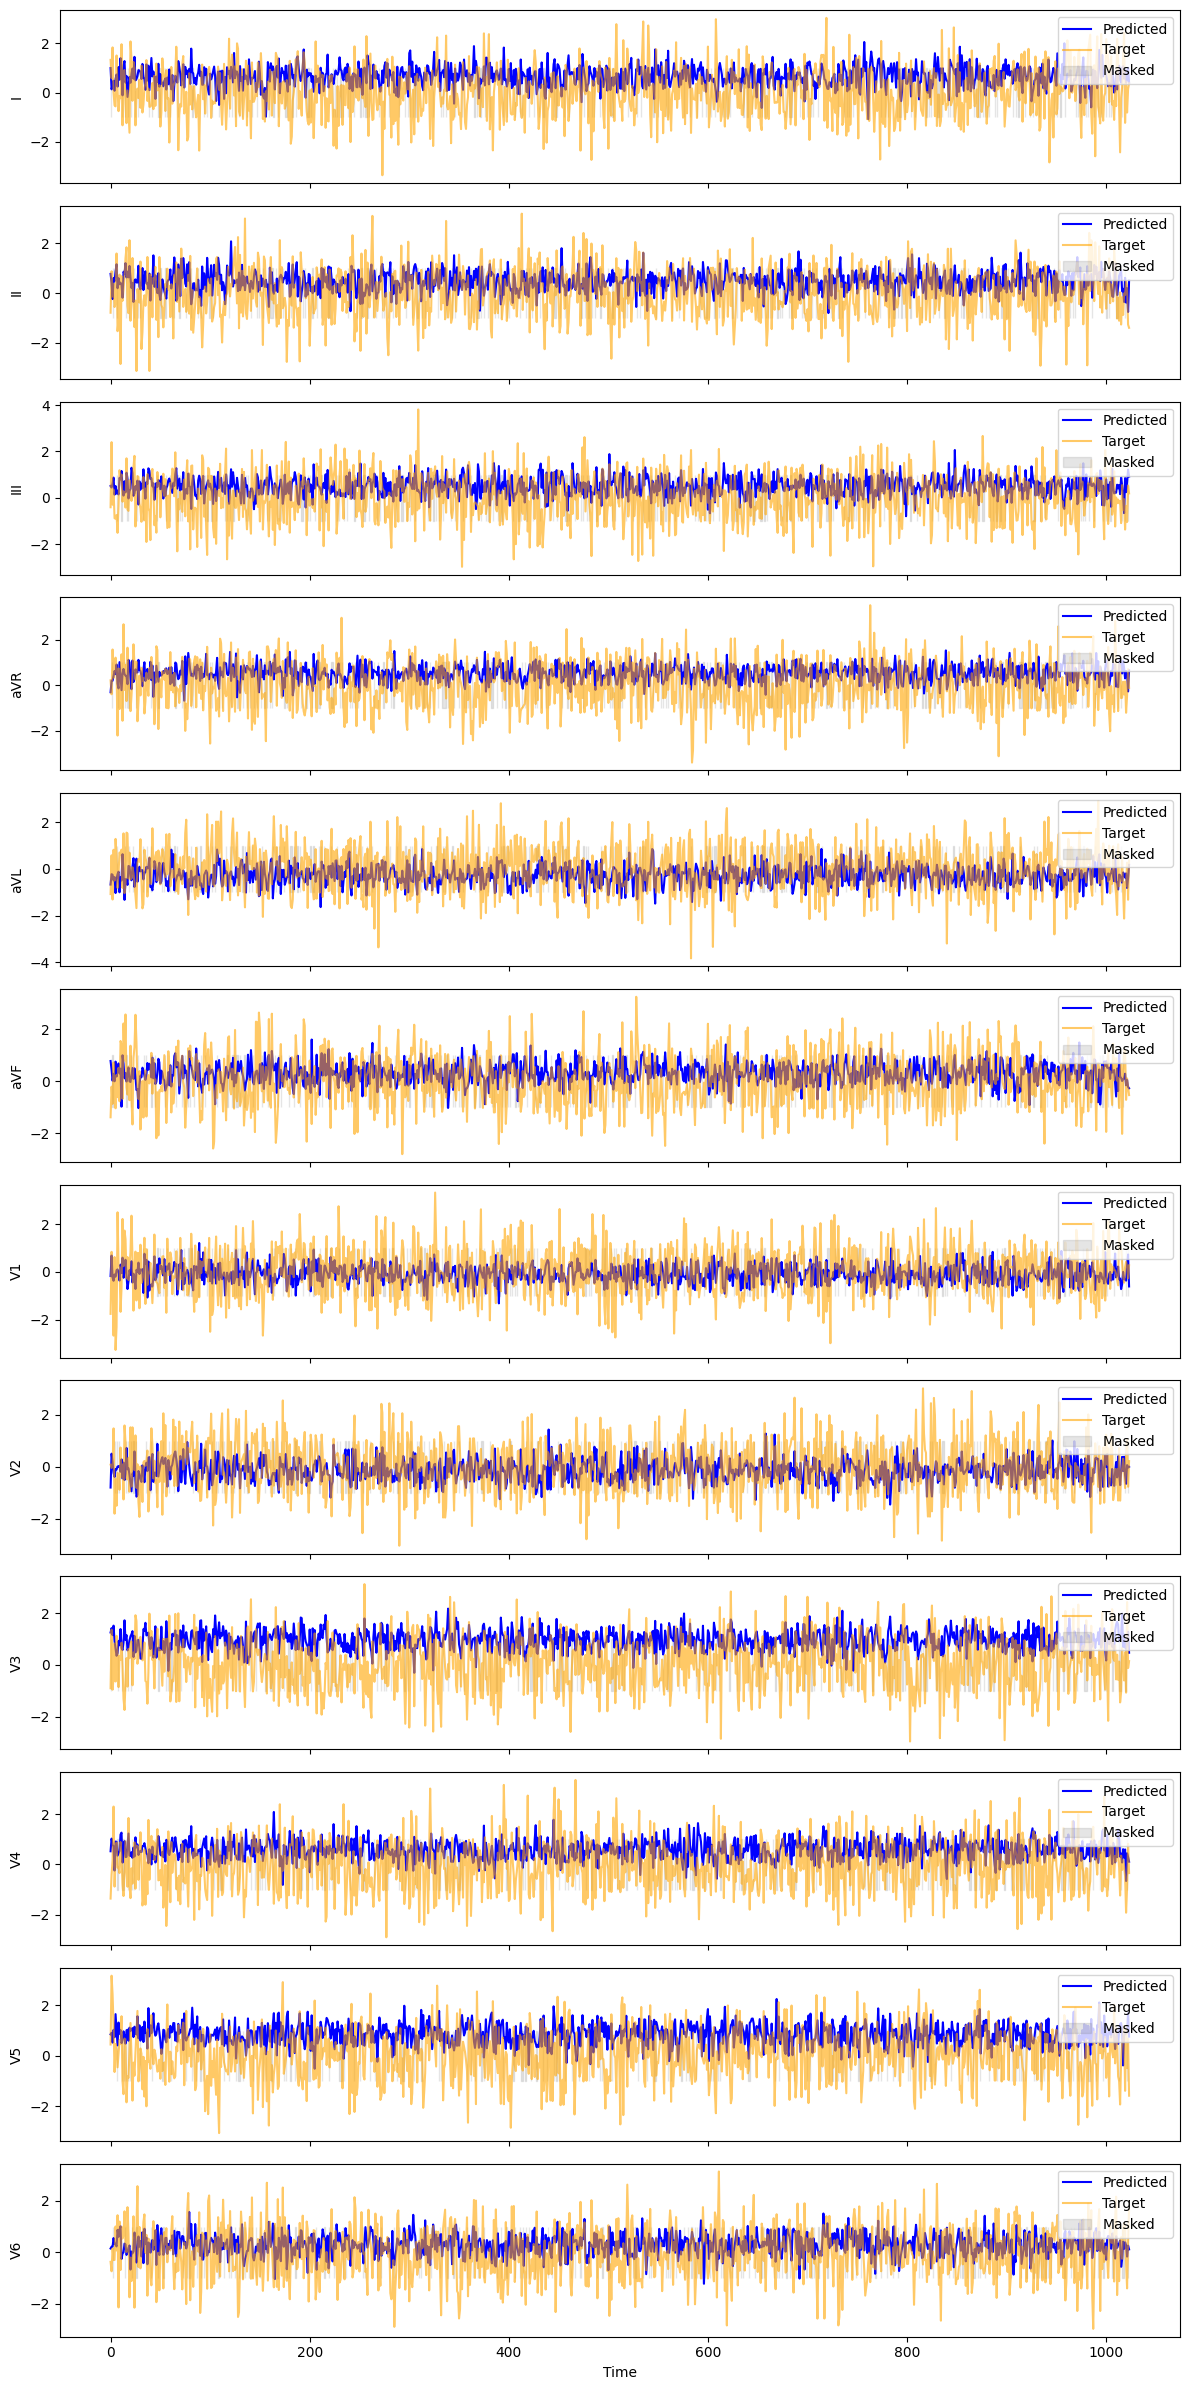

In [ ]:
# pred_waveform: (B, 12, T)
# target_waveform: (B, 12, T)
# mask_nan: (B, 12, T)

plot_ecg_waveforms(pred_waveform, target_waveform, mask_nan, sample_idx=0)


## PNG読み込みを追加したい。

In [ ]:
from PIL import Image
import random
import torchvision.transforms as T

class ECGImageWaveformDataset(Dataset):
    def __init__(self, meta_df, config, transform=None):
        self.meta_df = meta_df.reset_index(drop=True)
        self.config = config
        self.transform = transform or T.Compose([
            T.Resize((224, 224)),
            T.ToTensor()
        ])

    def __getitem__(self, idx):
        row = self.meta_df.iloc[idx]
        ecg_id = str(row["id"])

        # --- 画像選択（ランダム1枚） ---
        png_list = list((self.config.train_data_dir / ecg_id).glob("*.png"))
        png_path = random.choice(png_list)
        image = Image.open(png_path).convert("RGB")
        image_tensor = self.transform(image)  # (3, 224, 224)

        # --- 波形読み込み（CSV） ---
        csv_path = list((self.config.train_data_dir / ecg_id).glob("*.csv"))[0]
        ecg_df = pd.read_csv(csv_path).astype(np.float32)
        ecg_array = ecg_df.to_numpy().T  # (12, T)
        ecg_tensor = torch.from_numpy(ecg_array)
        mask_nan = ~torch.isnan(ecg_tensor)
        mask_valid = mask_nan.any(dim=0)

        return {
            "id": ecg_id,
            "image": image_tensor,
            "ecg": ecg_tensor,
            "mask_nan": mask_nan,
            "mask_valid": mask_valid,
            "length": ecg_tensor.shape[1]
        }

## MODELの手法

✅ 構成概要
- Optimizer: AdamW
- Scheduler: Warmup + CosineAnnealingLR
- Layer-wise LR Decay: 下層ほど学習率を小さく設定
- Gradient Accumulation: オプションで対応可能（コメント付き）

✅ ViTでWarmupが好まれる理由
- Transformerは初期の重みで不安定になりやすく、急激な学習率が破綻を招く
- Warmupにより、安定したAttentionの形成と勾配流れが保証される
- 事前学習済みモデルの微調整でも、Warmupは破壊的な更新を防ぐ

✅ Gradient Accumulationが有効な理由
- ViTは計算量・メモリ消費が大きいため、大バッチでの学習が理想
- GPUメモリが足りない場合でも、小バッチを複数回 accumulate することで大バッチ相当の更新が可能
- 特に画像＋波形のようなマルチモーダル構成では、メモリ効率が重要


In [ ]:
# ✅ 1. Layer-wise LR Decay の optimizer 構成
def get_layerwise_optimizer(model, base_lr=1e-4, decay_rate=0.95, weight_decay=0.01):
    """
    ViTやTransformer系モデルに対して、層ごとに学習率を減衰させるoptimizerを構築
    """
    param_groups = []
    num_layers = len(list(model.parameters()))
    for i, (name, param) in enumerate(model.named_parameters()):
        if not param.requires_grad:
            continue
        layer_lr = base_lr * (decay_rate ** (num_layers - i))
        param_groups.append({"params": param, "lr": layer_lr, "weight_decay": weight_decay})
    return torch.optim.AdamW(param_groups)

In [ ]:
#✅ 2. Warmup付き CosineAnnealingLR の scheduler 構成
class WarmupCosineScheduler(torch.optim.lr_scheduler._LRScheduler):
    def __init__(self, optimizer, warmup_steps, total_steps, last_epoch=-1):
        self.warmup_steps = warmup_steps
        self.total_steps = total_steps
        super().__init__(optimizer, last_epoch)

    def get_lr(self):
        step = self.last_epoch + 1
        if step < self.warmup_steps:
            return [base_lr * step / self.warmup_steps for base_lr in self.base_lrs]
        else:
            progress = (step - self.warmup_steps) / (self.total_steps - self.warmup_steps)
            return [base_lr * 0.5 * (1 + torch.cos(torch.tensor(progress * 3.14159265))) for base_lr in self.base_lrs]

✅ 3. 学習・バリデーションループ（テンプレート）

In [ ]:
model = ECGImageToWaveformModel(seq_len=1024, num_leads=12)
model.train()

optimizer = get_layerwise_optimizer(model, base_lr=1e-4)
total_steps = len(train_loader) * num_epochs
scheduler = WarmupCosineScheduler(optimizer, warmup_steps=500, total_steps=total_steps)

# --- 損失関数 ---
def masked_mse(pred, target, mask):
    diff = (pred - target) ** 2
    return diff[mask].mean()

# --- 学習ループ ---
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for step, batch in enumerate(train_loader):
        x_img = batch["image"]             # (B, 3, 224, 224)
        target = batch["ecg"]              # (B, 12, T)
        mask_nan = batch["mask_nan"]       # (B, 12, T)

        optimizer.zero_grad()
        pred = model(x_img)                # (B, 12, T)
        loss = masked_mse(pred, target, mask_nan)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

    # --- バリデーション ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x_img = batch["image"]
            target = batch["ecg"]
            mask_nan = batch["mask_nan"]

            pred = model(x_img)
            loss = masked_mse(pred, target, mask_nan)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)
    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

NameError: name 'train_loader' is not defined

✅ 拡張ポイント
- Gradient Accumulation を入れる場合は loss = loss / accum_steps → if step % accum_steps == 0: で optimizer.step() を制御
- mask_valid を使って時間軸の有効範囲だけで損失を計算することも可能
- wandb や TensorBoard にログを送ることで学習曲線を可視化可能


もちろんです、洋平さん。
以下は、先ほどの学習・バリデーションループに対応した Weights & Biases（wandb）ログのテンプレートです。
ViT系モデルやマルチモーダル学習でも使いやすいように、学習率・損失・画像・波形などを柔軟に記録できる構成になっています。

In [ ]:
import wandb

wandb.init(
    project="ecg-image-to-waveform",
    name=f"run-{model.__class__.__name__}",
    config={
        "lr": 1e-4,
        "optimizer": "AdamW",
        "scheduler": "WarmupCosine",
        "warmup_steps": 500,
        "epochs": num_epochs,
        "model": model.__class__.__name__,
        "seq_len": 1024,
        "num_leads": 12
    }
)

ModuleNotFoundError: No module named 'wandb'

# ✅ 2. 学習ループ内のログ記録

In [ ]:
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0

    for step, batch in enumerate(train_loader):
        x_img = batch["image"]
        target = batch["ecg"]
        mask_nan = batch["mask_nan"]

        optimizer.zero_grad()
        pred = model(x_img)
        loss = masked_mse(pred, target, mask_nan)
        loss.backward()
        optimizer.step()
        scheduler.step()

        train_loss += loss.item()

        # --- wandb ログ（ステップ単位） ---
        wandb.log({
            "train/loss": loss.item(),
            "train/lr": scheduler.get_last_lr()[0]
        })

    # --- バリデーション ---
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for batch in val_loader:
            x_img = batch["image"]
            target = batch["ecg"]
            mask_nan = batch["mask_nan"]

            pred = model(x_img)
            loss = masked_mse(pred, target, mask_nan)
            val_loss += loss.item()

    avg_train_loss = train_loss / len(train_loader)
    avg_val_loss = val_loss / len(val_loader)

    # --- wandb ログ（エポック単位） ---
    wandb.log({
        "epoch": epoch + 1,
        "train/avg_loss": avg_train_loss,
        "val/avg_loss": avg_val_loss
    })

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

NameError: name 'train_loader' is not defined

In [ ]:
def log_waveform_to_wandb(pred, target, sample_idx=0):
    import matplotlib.pyplot as plt
    import io

    fig, axes = plt.subplots(12, 1, figsize=(10, 20), sharex=True)
    for i in range(12):
        axes[i].plot(pred[sample_idx, i].cpu(), label="Pred", color="blue")
        axes[i].plot(target[sample_idx, i].cpu(), label="Target", color="orange", alpha=0.6)
        axes[i].set_ylabel(f"Lead {i+1}")
        axes[i].legend()

    plt.tight_layout()
    buf = io.BytesIO()
    plt.savefig(buf, format='png')
    buf.seek(0)
    wandb.log({"waveform_comparison": wandb.Image(buf)})
    plt.close()

In [86]:
signal = extract_lead_signal(ecg_df, lead="I")
#平滑化
fs =1000

In [87]:
from scipy.signal import butter, lfilter

def highpass_filter(signal: np.ndarray, cutoff_hz: float, fs: int, order: int = 5) -> np.ndarray:
    """ハイパスフィルタ（バターワース）を適用し、ベースラインドリフトを除去する"""
    nyq = 0.5 * fs
    normal_cutoff = cutoff_hz / nyq
    
    # バターワースフィルタの係数を設計
    b, a = butter(order, normal_cutoff, btype='high', analog=False)
    
    # 信号にフィルタを適用 (双方向フィルタリングで位相歪みを回避)
    # lfilterの代わりにfiltfiltを使う方が、位相遅延を防げてECG解析では望ましい
    filtered_signal = lfilter(b, a, signal)
    
    return filtered_signal

# 使用例: 0.5 Hz以下の低周波ノイズを除去
# signal_filtered = highpass_filter(signal, cutoff_hz=0.5, fs=1000)